# EDA

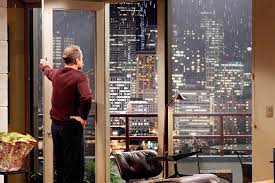

# Question to answer

**William Rodriguez - Buyer - 2 people, country (best timing & non-renovated) & city house (fast & central location), wants two houses**

- Where are houses located
- When are houses more sold

Hypothesis that i want to check:
- Houses with bigger area will sell for a higher price. 
     (city houses can be more expensive even though size is smaller)
- A larger average square footage of the 15 nearest neighbors (sqft_living15), which is an indicator of neighborhood quality, is positively correlated with the house's price.
- Older houses (yr_built) that have not been renovated will sell for a lower price compared to newer houses of similar size and features.

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import missingno as msno
from io import StringIO # creates an in-memory file-like object that behaves like a file, but stores its contents in a string instead of on disk.
from scipy import stats # for stat analysis
from matplotlib.ticker import PercentFormatter   # Import formatter to display axis values as percentages
from scipy.cluster import hierarchy
import folium
from folium import plugins
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time
from folium.plugins import MarkerCluster

# Update default Matplotlib settings for consistent plot appearance
plt.rcParams.update({
    "figure.figsize": (8, 5),      # Set default figure size
    "axes.facecolor": "white",     # Set plot background color
    "axes.edgecolor": "black"      # Set border color of the plot area
})

plt.rcParams["figure.facecolor"] = "w"            # Set overall figure background to white

pd.plotting.register_matplotlib_converters()      # Enable pandas datetime converters for Matplotlib plots

# Set pandas option to format floating-point numbers to 3 decimal places when displayed
pd.set_option('display.float_format', lambda x: '%.3f' % x)


# 1. Data Loading and Initial Inspection

In [2]:
print("\n## 1. Initial Data Inspection")
print("\n")

# importing data
df_eda = pd.read_csv('../eda.csv')
print(df_eda.head(10))

# make a copy of the file for further steps
# Make a copy of the DataFrame
df = df_eda.copy()



## 1. Initial Data Inspection


         date       price          id  bedrooms  bathrooms  sqft_living  \
0  2014-10-13  221900.000  7129300520     3.000      1.000     1180.000   
1  2014-12-09  538000.000  6414100192     3.000      2.250     2570.000   
2  2015-02-25  180000.000  5631500400     2.000      1.000      770.000   
3  2014-12-09  604000.000  2487200875     4.000      3.000     1960.000   
4  2015-02-18  510000.000  1954400510     3.000      2.000     1680.000   
5  2014-05-12 1230000.000  7237550310     4.000      4.500     5420.000   
6  2014-06-27  257500.000  1321400060     3.000      2.250     1715.000   
7  2015-01-15  291850.000  2008000270     3.000      1.500     1060.000   
8  2015-04-15  229500.000  2414600126     3.000      1.000     1780.000   
9  2015-03-12  323000.000  3793500160     3.000      2.500     1890.000   

    sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0   5650.000   1.000         NaN 0.000  ...      7    1180.0

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Number of properties: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print("\n")

print("=== DATA TYPES AND BASIC INFO ===")
# check for data types and statistics overview of data frame columns
print(df.info())

Dataset shape: (21597, 21)
Number of properties: 21597
Date range: 2014-05-02 to 2015-05-27


=== DATA TYPES AND BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21597 non-null  object 
 1   price          21597 non-null  float64
 2   id             21597 non-null  int64  
 3   bedrooms       21597 non-null  float64
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  float64
 6   sqft_lot       21597 non-null  float64
 7   floors         21597 non-null  float64
 8   waterfront     19206 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  float64
 13  sqft_basement  21145 non-null  float64
 14  yr_built       21597 non-null  int64  
 15  yr_renovat

In [4]:
# check data types in data frame
df.dtypes

date              object
price            float64
id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
dtype: object

In [5]:
# 2. Data Cleaning and Preparation 🧹
print("\n## 2. Data Cleaning and Preparation")

# Step 1: Convert the 'date' column to datetime objects.
df['date'] = pd.to_datetime(df['date'])

# check data types in data frame
df.dtypes



## 2. Data Cleaning and Preparation


date             datetime64[ns]
price                   float64
id                        int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront              float64
view                    float64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
dtype: object

# 2: Identify columns with missing value and impute / replace them


In [6]:
# Identify columns with missing values (NaN or empty string in this case).
    # The initial df.info() showed non-null counts, let's look for empty strings/NaN explicitly.
    # We'll replace empty strings with NaN for proper imputation/handling.
df = df.replace('', np.nan)

# display number of missing values per column

    ## df.isna(): This returns a DataFrame of the same shape as df, but with boolean values:
    ## True → the cell is missing (NaN, None, or NaT)
    ## False → the cell is not missing

df.isna().sum()  * 100 / len(df) # * 100 / len(df) gives the percentage of data missing


date             0.000
price            0.000
id               0.000
bedrooms         0.000
bathrooms        0.000
sqft_living      0.000
sqft_lot         0.000
floors           0.000
waterfront      11.071
view             0.292
condition        0.000
grade            0.000
sqft_above       0.000
sqft_basement    2.093
yr_built         0.000
yr_renovated    17.817
zipcode          0.000
lat              0.000
long             0.000
sqft_living15    0.000
sqft_lot15       0.000
dtype: float64

Why Imputation over Interpolation:
Non-temporal data: Your dataset isn't time-series data where interpolation makes sense. The dates are sale dates, not sequential measurements of the same property.

Categorical nature: Some missing fields like waterfront (likely 0/1) and view (ordinal scale 0-4) are categorical/ordinal, not continuous.

Small dataset: With only 25 records and few missing values, interpolation could introduce unnecessary complexity.

Missing pattern: The missing values are sporadic across different records and columns, not following a pattern that interpolation would help.

In [7]:
# For numerical columns (sqft_basement, yr_renovated):
    ## Use median or mode imputation
    ## For yr_renovated, 0 typically means "never renovated"

# For categorical/ordinal columns (waterfront, view):
    ## Use mode (most frequent value) imputation

    ## For waterfront, likely impute with 0 (not waterfront)
    ## For view, impute with 0 (no view)

# Check missing values BEFORE imputation
print("=== MISSING VALUES BEFORE IMPUTATION ===")
print(df.isnull().sum())
print("\n")


=== MISSING VALUES BEFORE IMPUTATION ===
date                0
price               0
id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64




In [8]:
# Impute numerical columns
# For sqft_basement: assuming missing values mean no basement (0 sqft)
df['sqft_basement'].fillna(0, inplace=True)

# For yr_renovated: assuming missing values mean never renovated (0)
df['yr_renovated'].fillna(0, inplace=True)

# Impute categorical columns  
# For waterfront: most properties are not waterfront, so impute with 0
df['waterfront'].fillna(0, inplace=True)

# For view: most properties have no view, so impute with 0
df['view'].fillna(0, inplace=True)

# Check missing values AFTER imputation
print("=== MISSING VALUES AFTER IMPUTATION ===")
print(df.isnull().sum())
print("\n")

=== MISSING VALUES AFTER IMPUTATION ===
date             0
price            0
id               0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64




In [9]:
print(df.head(10))

print(df.dtypes)

        date       price          id  bedrooms  bathrooms  sqft_living  \
0 2014-10-13  221900.000  7129300520     3.000      1.000     1180.000   
1 2014-12-09  538000.000  6414100192     3.000      2.250     2570.000   
2 2015-02-25  180000.000  5631500400     2.000      1.000      770.000   
3 2014-12-09  604000.000  2487200875     4.000      3.000     1960.000   
4 2015-02-18  510000.000  1954400510     3.000      2.000     1680.000   
5 2014-05-12 1230000.000  7237550310     4.000      4.500     5420.000   
6 2014-06-27  257500.000  1321400060     3.000      2.250     1715.000   
7 2015-01-15  291850.000  2008000270     3.000      1.500     1060.000   
8 2015-04-15  229500.000  2414600126     3.000      1.000     1780.000   
9 2015-03-12  323000.000  3793500160     3.000      2.500     1890.000   

    sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0   5650.000   1.000       0.000 0.000  ...      7    1180.000          0.000   
1   7242.000   2.000   

In [10]:
# Drop the 'id' column as it is an arbitrary identifier and has no predictive power.
df_2 = df.drop('id', axis=1)

# Correct the data types for 'floors', 'waterfront', and 'view' to be integers.
df_2['floors'] = df_2['floors'].astype(float).astype(int)
df_2['waterfront'] = df_2['waterfront'].astype(int)
df_2['view'] = df_2['view'].astype(float).astype(int)

print(df_2.dtypes)

date             datetime64[ns]
price                   float64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                    int64
waterfront                int64
view                      int64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
dtype: object


# 3. Descriptive Statistics

In [11]:

# Select numerical columns for statistical analysis
numerical_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
                  'floors', 'waterfront', 'view', 'condition', 'grade', 
                  'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
                  'lat', 'long', 'sqft_living15', 'sqft_lot15']

# Get descriptive statistics for numerical columns. 
# T transposes the table
print(df_2[numerical_cols].describe().T) 
print("\n")


                  count       mean        std       min        25%        50%  \
price         21597.000 540296.574 367368.140 78000.000 322000.000 450000.000   
bedrooms      21597.000      3.373      0.926     1.000      3.000      3.000   
bathrooms     21597.000      2.116      0.769     0.500      1.750      2.250   
sqft_living   21597.000   2080.322    918.106   370.000   1430.000   1910.000   
sqft_lot      21597.000  15099.409  41412.637   520.000   5040.000   7618.000   
floors        21597.000      1.446      0.552     1.000      1.000      1.000   
waterfront    21597.000      0.007      0.082     0.000      0.000      0.000   
view          21597.000      0.233      0.765     0.000      0.000      0.000   
condition     21597.000      3.410      0.651     1.000      3.000      3.000   
grade         21597.000      7.658      1.173     3.000      7.000      7.000   
sqft_above    21597.000   1788.597    827.760   370.000   1190.000   1560.000   
sqft_basement 21597.000    2

**Columns to analyse in details**
<blockquote>
- Price
- Grade
- Lat and long
<blockquote>


In [12]:
print("=== PRICE ANALYSIS ===")
print(f"Average price: ${df_2['price'].mean():,.2f}")
print(f"Median price: ${df_2['price'].median():,.2f}")
print(f"Price standard deviation: ${df_2['price'].std():,.2f}")
print(f"Minimum price: ${df_2['price'].min():,.2f}")
print(f"Maximum price: ${df_2['price'].max():,.2f}")
print(f"Price range: ${df_2['price'].max() - df_2['price'].min():,.2f}")
print("\n")

=== PRICE ANALYSIS ===
Average price: $540,296.57
Median price: $450,000.00
Price standard deviation: $367,368.14
Minimum price: $78,000.00
Maximum price: $7,700,000.00
Price range: $7,622,000.00





## 3. Univariate Analysis


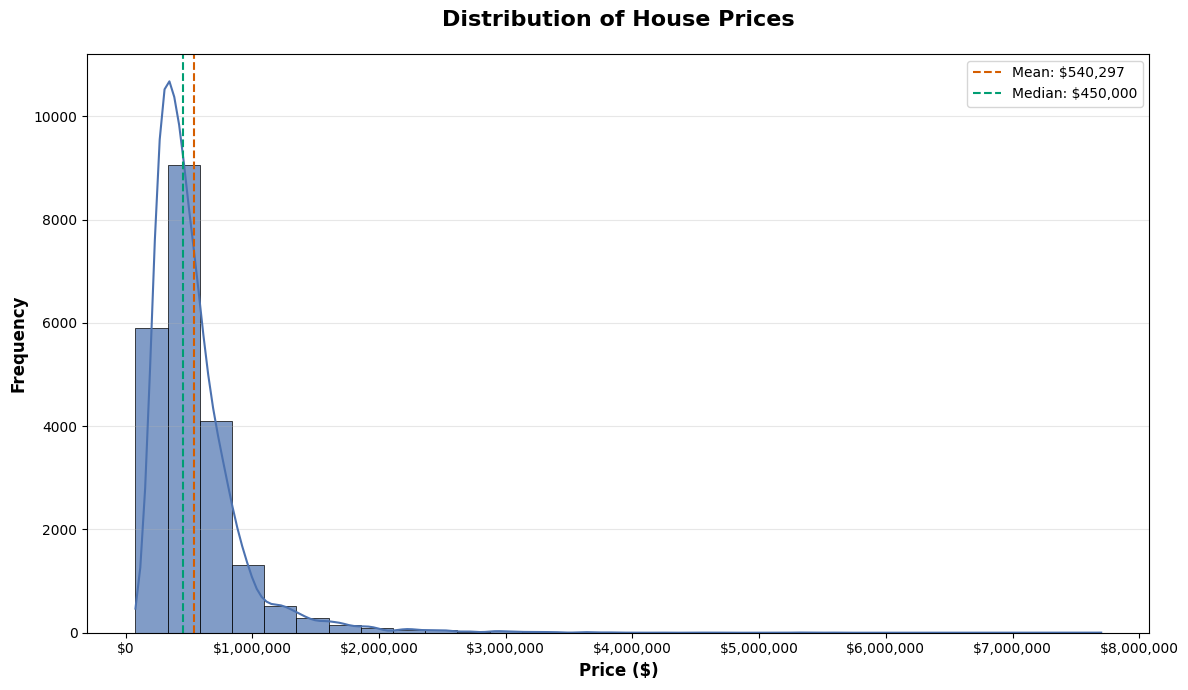

In [13]:
# 3. Univariate Analysis (Distribution of Key Variables)
print("\n## 3. Univariate Analysis")

# Plot the distribution of the target variable 'price'
plt.figure(figsize=(12, 7))

# Use a better bin calculation and add styling
sns.histplot(df['price'], 
             kde=True, 
             bins=30, 
             color='#4C72B0',  # Blue from colorblind-safe palette, 
             edgecolor='black', alpha=0.7, linewidth=0.5)

plt.title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Price ($)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Format x-axis to show dollar amounts properly
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add statistical annotations
mean_price = df['price'].mean()
median_price = df['price'].median()
plt.axvline(mean_price, color='#D55E00', linestyle='--', linewidth=1.5, 
            label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='#009E73', linestyle='--', linewidth=1.5, 
            label=f'Median: ${median_price:,.0f}')

plt.legend()
plt.tight_layout()
plt.show()

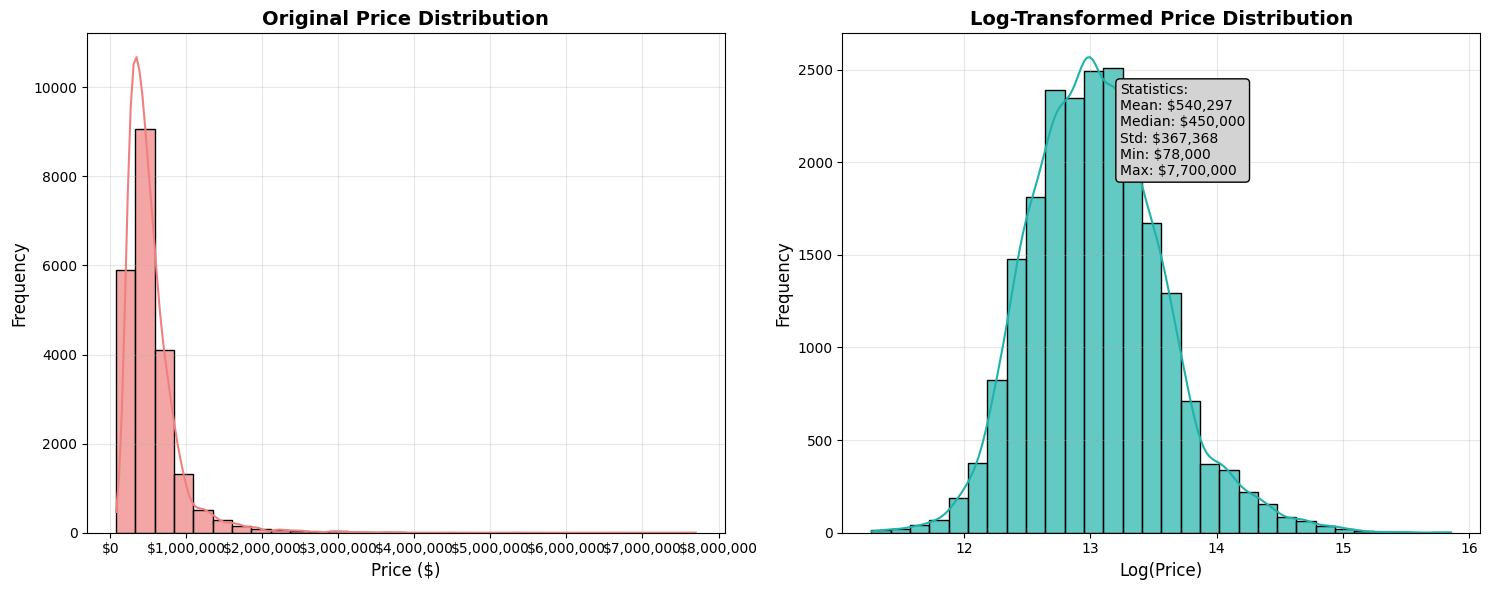

In [14]:
# Plot the distribution of the target variable 'price' with log transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original distribution
sns.histplot(df['price'], kde=True, bins=30, color='lightcoral', 
             edgecolor='black', alpha=0.7, ax=ax1)
ax1.set_title('Original Price Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Price ($)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Log-transformed distribution
sns.histplot(np.log1p(df['price']), kde=True, bins=30, color='lightseagreen', 
             edgecolor='black', alpha=0.7, ax=ax2)
ax2.set_title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Log(Price)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.grid(alpha=0.3)

# Add statistics box
stats_text = f"""Statistics:
Mean: ${df['price'].mean():,.0f}
Median: ${df['price'].median():,.0f}
Std: ${df['price'].std():,.0f}
Min: ${df['price'].min():,.0f}
Max: ${df['price'].max():,.0f}"""

fig.text(0.75, 0.70, stats_text, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"), 
         fontsize=10, transform=fig.transFigure)

plt.tight_layout()
plt.show()

=== PRICE CATEGORIES ===
Budget (<$250K): 2297 properties (avg: $205,969)
Affordable ($250K-$400K): 6384 properties (avg: $323,392)
Mid-Range ($400K-$600K): 6552 properties (avg: $489,777)
Premium ($600K-$1M): 4874 properties (avg: $748,011)
Luxury (>$1M): 1490 properties (avg: $1,527,732)

Overall average price: $540,297
Median price: $450,000


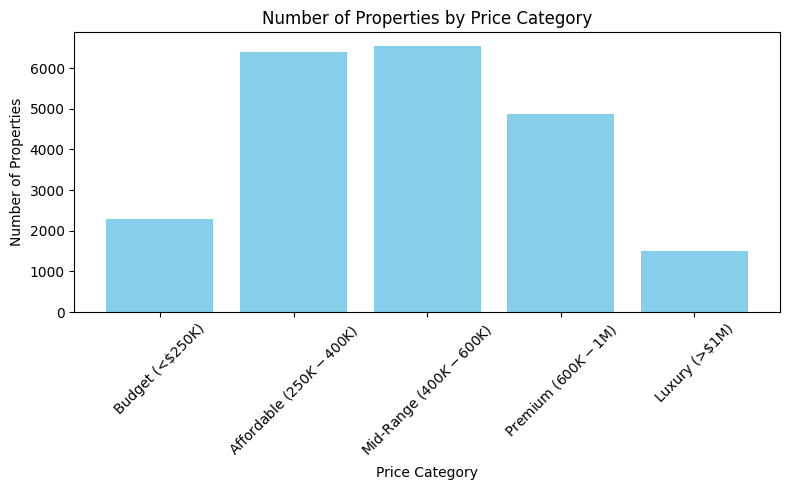

In [51]:


# === Price categories ===
print("=== PRICE CATEGORIES ===")

price_bins = [0, 250000, 400000, 600000, 1000000, float('inf')]
price_labels = [
    'Budget (<$250K)',
    'Affordable ($250K-$400K)',
    'Mid-Range ($400K-$600K)',
    'Premium ($600K-$1M)',
    'Luxury (>$1M)'
]

df['price_category'] = pd.cut(df['price'], bins=price_bins, labels=price_labels, right=False)
price_summary = df['price_category'].value_counts().sort_index()

# Print the counts and average prices for each category
for category, count in price_summary.items():
    avg_price = df[df['price_category'] == category]['price'].mean()
    print(f"{category}: {count} properties (avg: ${avg_price:,.0f})")

# Print overall statistics
print(f"\nOverall average price: ${df['price'].mean():,.0f}")
print(f"Median price: ${df['price'].median():,.0f}")

# === Plotting ===

# Create a bar chart for price categories
plt.figure(figsize=(8,5))  # Set figure size
plt.bar(price_summary.index, price_summary.values, color='skyblue')
plt.title('Number of Properties by Price Category')  # Chart title
plt.xlabel('Price Category')  # X-axis label
plt.ylabel('Number of Properties')  # Y-axis label
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout so labels fit nicely
plt.show()


In [52]:
# 2. GRADE CATEGORIES
print("\n=== GRADE CATEGORIES ===")
# Grade interpretation (typical scale):
# 6-7: Average, 8: Good, 9: Better, 10: Very Good, 11: Excellent, 12-13: Luxury
grade_bins = [0, 6, 7, 8, 9, 10, float('inf')]
grade_labels = ['Below Average (1-6)', 'Average (7)', 'Good (8)', 'Very Good (9)', 
                'Excellent (10)', 'Luxury (11+)']

df['grade_category'] = pd.cut(df['grade'], bins=grade_bins, labels=grade_labels, right=False)
grade_summary = df['grade_category'].value_counts().sort_index()

for category, count in grade_summary.items():
    avg_grade = df[df['grade_category'] == category]['grade'].mean()
    avg_price = df[df['grade_category'] == category]['price'].mean()
    print(f"{category}: {count} properties (avg grade: {avg_grade:.1f}, avg price: ${avg_price:,.0f})")



=== GRADE CATEGORIES ===
Below Average (1-6): 270 properties (avg grade: 4.9, avg price: $244,922)
Average (7): 2038 properties (avg grade: 6.0, avg price: $301,917)
Good (8): 8974 properties (avg grade: 7.0, avg price: $402,595)
Very Good (9): 6065 properties (avg grade: 8.0, avg price: $542,987)
Excellent (10): 2615 properties (avg grade: 9.0, avg price: $773,738)
Luxury (11+): 1635 properties (avg grade: 10.4, avg price: $1,258,670)


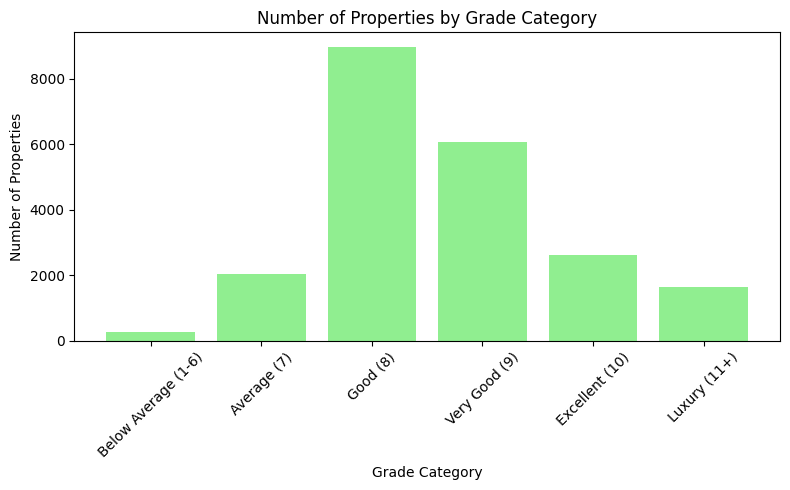

In [53]:
# === Plotting ===
plt.figure(figsize=(8,5))
plt.bar(grade_summary.index, grade_summary.values, color='lightgreen')
plt.title('Number of Properties by Grade Category')
plt.xlabel('Grade Category')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)  # Rotate labels for readability
plt.tight_layout()
plt.show()

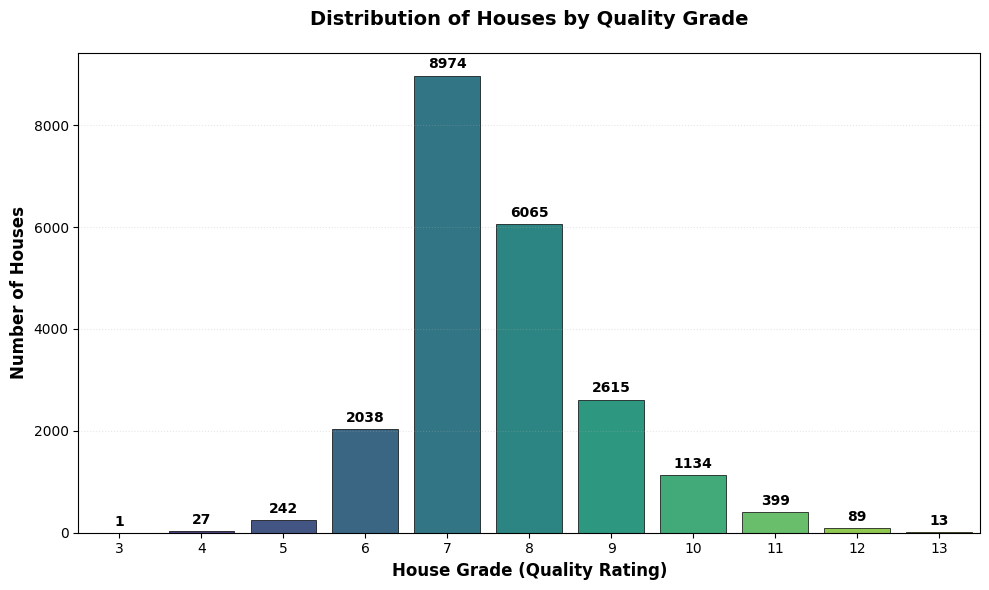

In [15]:
# Comment: Plot the count of houses by 'grade' (a measure of quality).
plt.figure(figsize=(10, 6))

# Use colorblind-friendly palette and add patterns
ax = sns.countplot(x='grade', data=df, palette='viridis', 
                   saturation=0.8, edgecolor='black', linewidth=0.5)

plt.title('Distribution of Houses by Quality Grade', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('House Grade (Quality Rating)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Houses', fontsize=12, fontweight='bold')

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', color='black', padding=3)

# Improve grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle=':')

# Use colorblind-friendly color palette
sns.set_palette("colorblind")

plt.tight_layout()
plt.show()

In [54]:
# 3. BEDROOM CATEGORIES
print("\n=== BEDROOM CATEGORIES ===")
bedroom_bins = [0, 2, 3, 4, float('inf')]
bedroom_labels = ['Small (1-2)', 'Medium (3)', 'Large (4)', 'Extra Large (5+)']

df['bedroom_category'] = pd.cut(df['bedrooms'], bins=bedroom_bins, labels=bedroom_labels, right=False)
bedroom_summary = df['bedroom_category'].value_counts().sort_index()

for category, count in bedroom_summary.items():
    avg_bedrooms = df[df['bedroom_category'] == category]['bedrooms'].mean()
    avg_price = df[df['bedroom_category'] == category]['price'].mean()
    print(f"{category}: {count} properties (avg bedrooms: {avg_bedrooms:.1f}, avg price: ${avg_price:,.0f})")



=== BEDROOM CATEGORIES ===
Small (1-2): 196 properties (avg bedrooms: 1.0, avg price: $318,239)
Medium (3): 2760 properties (avg bedrooms: 2.0, avg price: $401,388)
Large (4): 9824 properties (avg bedrooms: 3.0, avg price: $466,277)
Extra Large (5+): 8817 properties (avg bedrooms: 4.3, avg price: $671,190)


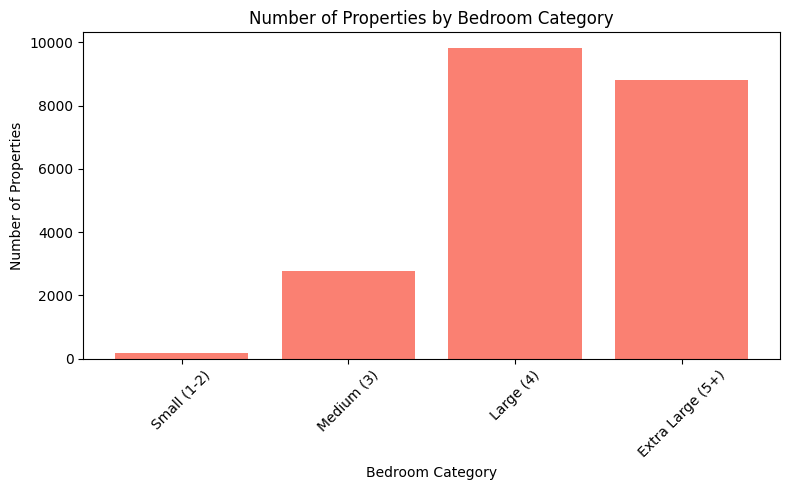

In [55]:
# === Plotting ===
plt.figure(figsize=(8,5))
plt.bar(bedroom_summary.index, bedroom_summary.values, color='salmon')
plt.title('Number of Properties by Bedroom Category')
plt.xlabel('Bedroom Category')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)  # Rotate labels for readability
plt.tight_layout()
plt.show()

In [56]:
# 4. DETAILED STATISTICS
print("\n=== DETAILED STATISTICS ===")
print("\nPrice Statistics:")
print(f"Minimum: ${df['price'].min():,.0f}")
print(f"25th percentile: ${df['price'].quantile(0.25):,.0f}")
print(f"Median: ${df['price'].median():,.0f}")
print(f"75th percentile: ${df['price'].quantile(0.75):,.0f}")
print(f"Maximum: ${df['price'].max():,.0f}")

print("\nGrade Statistics:")
grade_counts = df['grade'].value_counts().sort_index()
for grade, count in grade_counts.items():
    print(f"Grade {grade}: {count} properties")

print("\nBedroom Statistics:")
bedroom_counts = df['bedrooms'].value_counts().sort_index()
for beds, count in bedroom_counts.items():
    print(f"{beds} bedrooms: {count} properties")



=== DETAILED STATISTICS ===

Price Statistics:
Minimum: $78,000
25th percentile: $322,000
Median: $450,000
75th percentile: $645,000
Maximum: $7,700,000

Grade Statistics:
Grade 3: 1 properties
Grade 4: 27 properties
Grade 5: 242 properties
Grade 6: 2038 properties
Grade 7: 8974 properties
Grade 8: 6065 properties
Grade 9: 2615 properties
Grade 10: 1134 properties
Grade 11: 399 properties
Grade 12: 89 properties
Grade 13: 13 properties

Bedroom Statistics:
1.0 bedrooms: 196 properties
2.0 bedrooms: 2760 properties
3.0 bedrooms: 9824 properties
4.0 bedrooms: 6882 properties
5.0 bedrooms: 1601 properties
6.0 bedrooms: 272 properties
7.0 bedrooms: 38 properties
8.0 bedrooms: 13 properties
9.0 bedrooms: 6 properties
10.0 bedrooms: 3 properties
11.0 bedrooms: 1 properties
33.0 bedrooms: 1 properties

=== CROSS CATEGORY ANALYSIS ===

Price vs Bedroom Categories:
price_category    Budget (<$250K)  Affordable ($250K-$400K)  \
bedroom_category                                              
Smal

In [ ]:
# 5. CROSS ANALYSIS
print("\n=== CROSS CATEGORY ANALYSIS ===")
print("\nPrice vs Bedroom Categories:")
cross_tab = pd.crosstab(df['bedroom_category'], df['price_category'])
print(cross_tab)


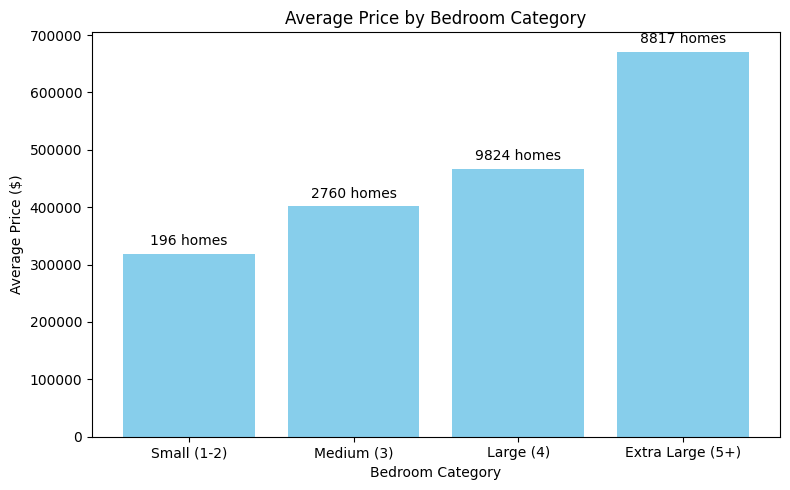

In [58]:

# Calculate the average price for each bedroom category
avg_price_per_bedroom = df.groupby('bedroom_category')['price'].mean()

# Count of properties for reference (optional for labeling)
count_per_bedroom = df['bedroom_category'].value_counts().sort_index()

plt.figure(figsize=(8,5))

# Bar chart for average price
bars = plt.bar(
    avg_price_per_bedroom.index,
    avg_price_per_bedroom.values,
    color='skyblue'
)

# Add the number of properties on top of each bar
for bar, count in zip(bars, count_per_bedroom):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10000, f"{count} homes",
             ha='center', va='bottom', fontsize=10)

plt.title('Average Price by Bedroom Category')
plt.xlabel('Bedroom Category')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [59]:
print("\nPrice vs Grade Categories:")
cross_tab2 = pd.crosstab(df['grade_category'], df['price_category'])
print(cross_tab2)


Price vs Grade Categories:
price_category       Budget (<$250K)  Affordable ($250K-$400K)  \
grade_category                                                   
Below Average (1-6)              162                        86   
Average (7)                      804                       859   
Good (8)                        1219                      3757   
Very Good (9)                    111                      1518   
Excellent (10)                     1                       159   
Luxury (11+)                       0                         5   

price_category       Mid-Range ($400K-$600K)  Premium ($600K-$1M)  \
grade_category                                                      
Below Average (1-6)                       18                    4   
Average (7)                              329                   41   
Good (8)                                3013                  958   
Very Good (9)                           2525                 1709   
Excellent (10)               

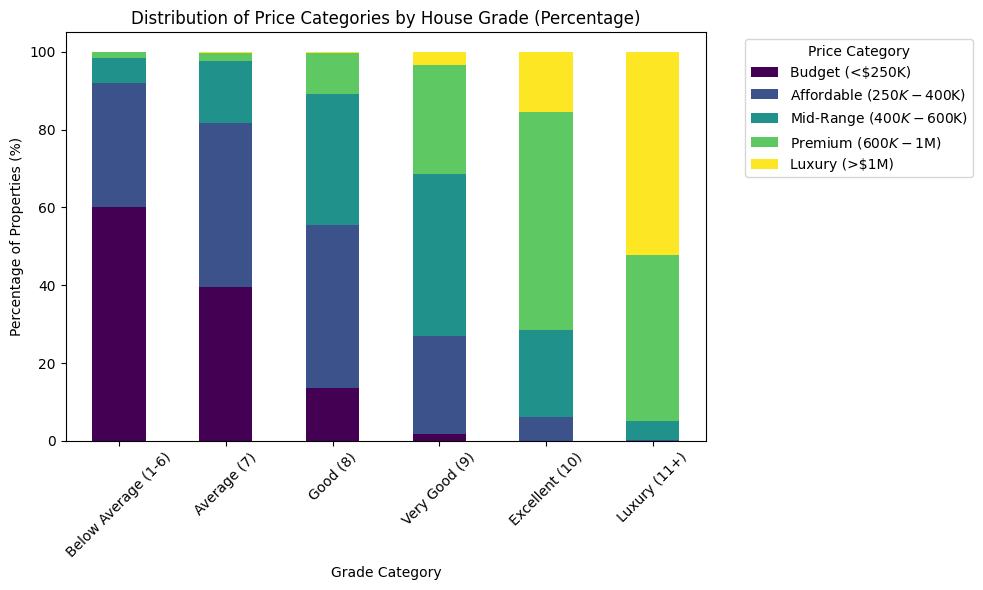

In [61]:
# Create the cross-tab
cross_tab2 = pd.crosstab(df['grade_category'], df['price_category'])

# Optionally, normalize to percentages for easier comparison
cross_tab2_norm = cross_tab2.div(cross_tab2.sum(axis=1), axis=0) * 100

# Plot a stacked bar chart
cross_tab2_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.title('Distribution of Price Categories by House Grade (Percentage)')
plt.xlabel('Grade Category')
plt.ylabel('Percentage of Properties (%)')
plt.xticks(rotation=45)
plt.legend(title='Price Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<Figure size 1400x1200 with 0 Axes>

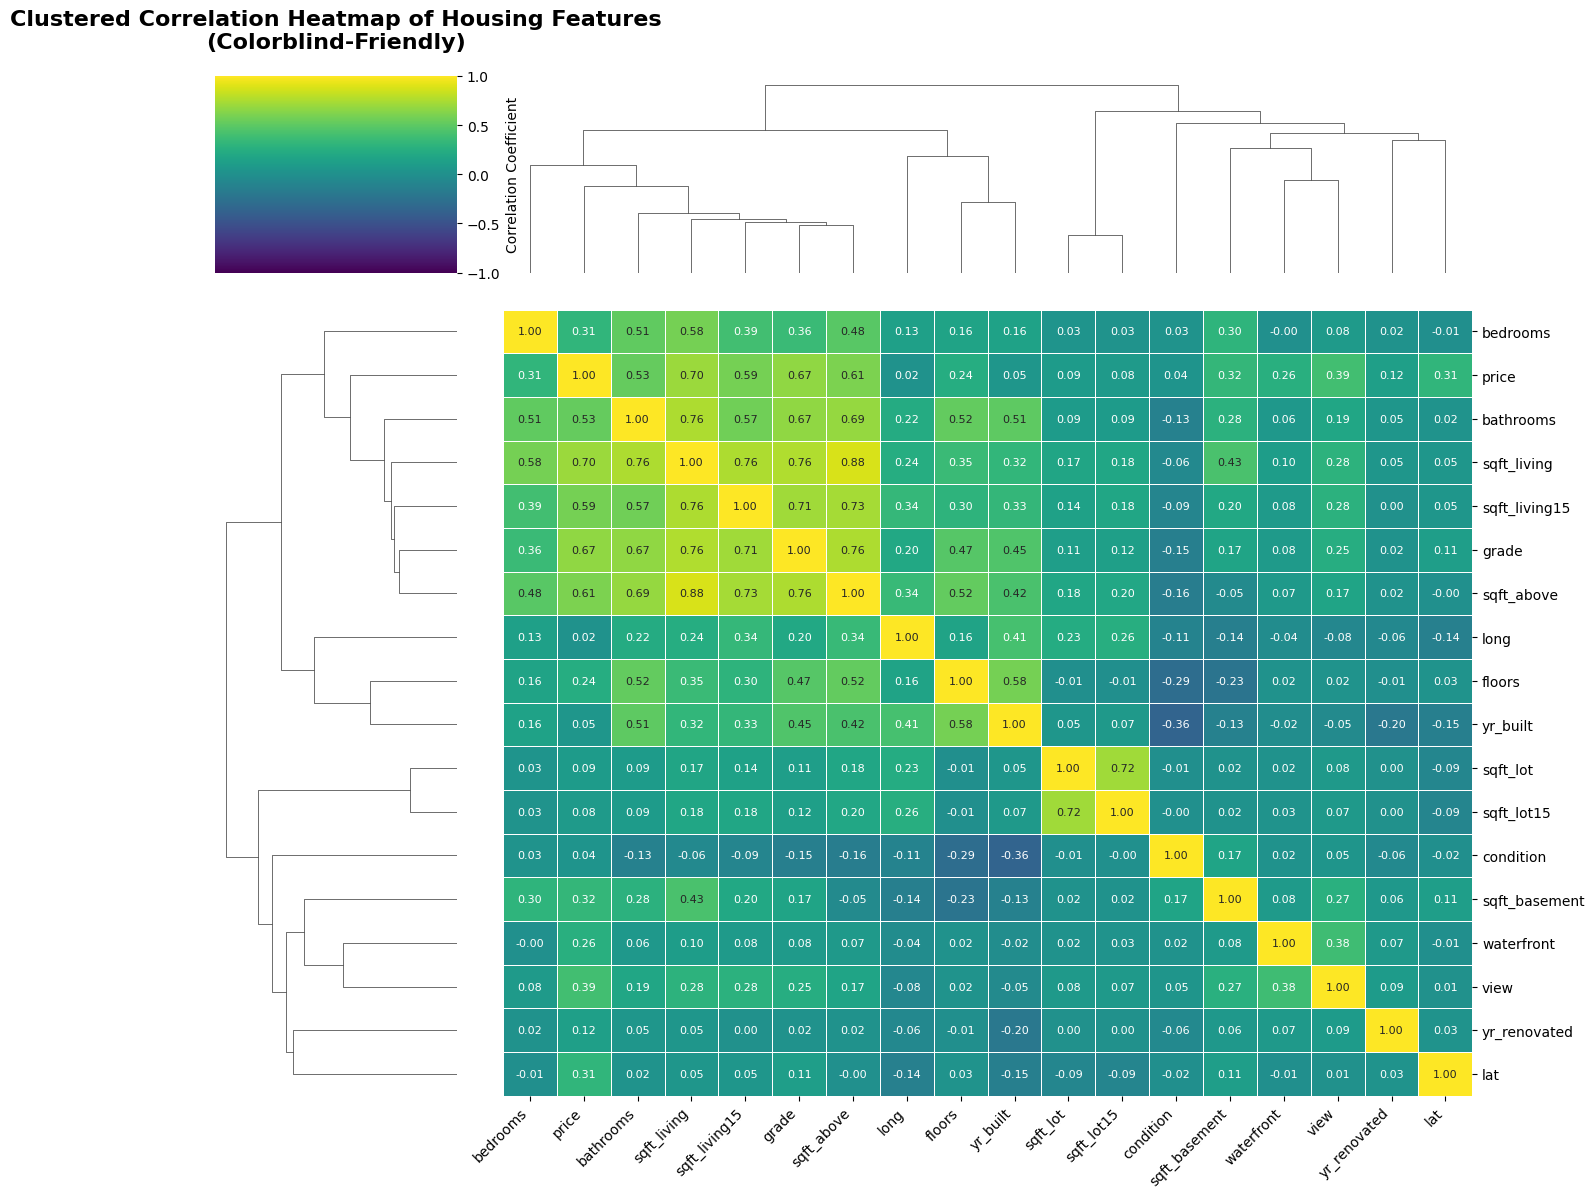

Feature Correlation Insights:

Strongest Positive Correlations:
sqft_above   sqft_living     0.876
sqft_living  sqft_above      0.876
             grade           0.763
grade        sqft_living     0.763
sqft_living  sqft_living15   0.756
dtype: float64

Strongest Negative Correlations:
condition      yr_built    -0.362
yr_built       condition   -0.362
condition      floors      -0.293
floors         condition   -0.293
sqft_basement  floors      -0.232
dtype: float64


In [16]:
df_2.head(5)

# Calculate correlation matrix
corr_matrix = df_2[numerical_cols].corr()

# Create clustered heatmap with colorblind-friendly colors
plt.figure(figsize=(14, 12))

# Create clustered heatmap using seaborn's clustermap
# - Centers the color scale at 0 to highlight positive vs. negative correlations
# - Displays correlation values inside each cell (formatted to 2 decimals)
# - Adds thin white grid lines for readability
# - Fixes the color scale between -1 and 1 (valid correlation range)
# - Includes a labeled colorbar
# - Produces a larger figure size for better visibility

g = sns.clustermap(corr_matrix, 
                   cmap='viridis',  # Colorblind-friendly
                   center=0,
                   annot=True,  # Show correlation values
                   fmt='.2f',   # Format to 2 decimal places
                   annot_kws={'size': 8},
                   linewidths=0.5,
                   linecolor='white',
                   cbar_kws={'label': 'Correlation Coefficient'},
                   vmin=-1, vmax=1,  # Fixed scale for correlations
                   figsize=(14, 12))
# Improve readability
plt.title('Clustered Correlation Heatmap of Housing Features\n(Colorblind-Friendly)', 
          fontsize=16, fontweight='bold', pad=20)

# Rotate x-axis labels for better readability
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right')

# Adjust layout
plt.tight_layout()
plt.show()

# Print some insights
print("Feature Correlation Insights:")
print("=" * 50)

# Identify strong positive correlations:
# - Convert the correlation matrix into a Series using unstack(), then sort values in descending order
# - Remove self-correlations (which are always 1.0) by filtering out values ≥ 0.999
strong_pos_corr = corr_matrix.unstack().sort_values(ascending=False)
strong_pos_corr = strong_pos_corr[strong_pos_corr < 0.999]

print("\nStrongest Positive Correlations:")
print(strong_pos_corr.head(5))

print("\nStrongest Negative Correlations:")
strong_neg_corr = corr_matrix.unstack().sort_values()
print(strong_neg_corr.head(5))

### Locating the houses geographically

## Analysing data for my client

In [ ]:
## 1-2 bedroom apartments in grade average or above

In [65]:
print("=== HOUSES WITH 1-2 BEDROOMS AND AVERAGE OR ABOVE GRADE ===\n")

# Step 1: Filter for 1-2 bedrooms
one_two_bedrooms = df[(df['bedrooms'] >= 1) & (df['bedrooms'] <= 2)]
print(f"Found {len(one_two_bedrooms)} houses with 1-2 bedrooms")

# Step 2: Filter for average or above grade (grade 7 or higher)
# In housing data, grade 7 is typically considered "average"
good_houses = one_two_bedrooms[one_two_bedrooms['grade'] >= 7]
print(f"Found {len(good_houses)} houses with 1-2 bedrooms AND grade 7 or above\n")

=== HOUSES WITH 1-2 BEDROOMS AND AVERAGE OR ABOVE GRADE ===

Found 2956 houses with 1-2 bedrooms
Found 1876 houses with 1-2 bedrooms AND grade 7 or above



In [66]:
# Step 3: Display the results in a nice table
print("MATCHING HOUSES:")
print("=" * 100)

for index, house in good_houses.iterrows():
    print(f"Date: {house['date']}")
    print(f"Price: ${house['price']:,.0f}")
    print(f"Bedrooms: {house['bedrooms']}")
    print(f"Bathrooms: {house['bathrooms']}")
    print(f"Grade: {house['grade']}")
    print(f"Living Area: {house['sqft_living']} sqft")
    print(f"Year Built: {house['yr_built']}")
    print(f"Zipcode: {house['zipcode']}")
    print("-" * 50)

MATCHING HOUSES:
Date: 2014-05-27 00:00:00
Price: $468,000
Bedrooms: 2.0
Bathrooms: 1.0
Grade: 7
Living Area: 1160.0 sqft
Year Built: 1942
Zipcode: 98115
--------------------------------------------------
Date: 2014-12-05 00:00:00
Price: $189,000
Bedrooms: 2.0
Bathrooms: 1.0
Grade: 7
Living Area: 1200.0 sqft
Year Built: 1921
Zipcode: 98002
--------------------------------------------------
Date: 2014-05-16 00:00:00
Price: $252,700
Bedrooms: 2.0
Bathrooms: 1.5
Grade: 7
Living Area: 1070.0 sqft
Year Built: 1985
Zipcode: 98030
--------------------------------------------------
Date: 2014-12-01 00:00:00
Price: $280,000
Bedrooms: 2.0
Bathrooms: 1.5
Grade: 7
Living Area: 1190.0 sqft
Year Built: 2005
Zipcode: 98133
--------------------------------------------------
Date: 2015-02-05 00:00:00
Price: $585,000
Bedrooms: 2.0
Bathrooms: 1.75
Grade: 7
Living Area: 1980.0 sqft
Year Built: 1981
Zipcode: 98117
--------------------------------------------------
Date: 2014-10-28 00:00:00
Price: $355,000


In [67]:
# Step 4: Show some statistics
print("\n=== STATISTICS ===")
print(f"Total matching houses: {len(good_houses)}")
print(f"Average price: ${good_houses['price'].mean():,.0f}")
print(f"Minimum price: ${good_houses['price'].min():,.0f}")
print(f"Maximum price: ${good_houses['price'].max():,.0f}")
print(f"Average living area: {good_houses['sqft_living'].mean():.0f} sqft")


=== STATISTICS ===
Total matching houses: 1876
Average price: $456,119
Minimum price: $90,000
Maximum price: $3,280,000
Average living area: 1372 sqft



Creating plots...


<Figure size 1500x1000 with 0 Axes>

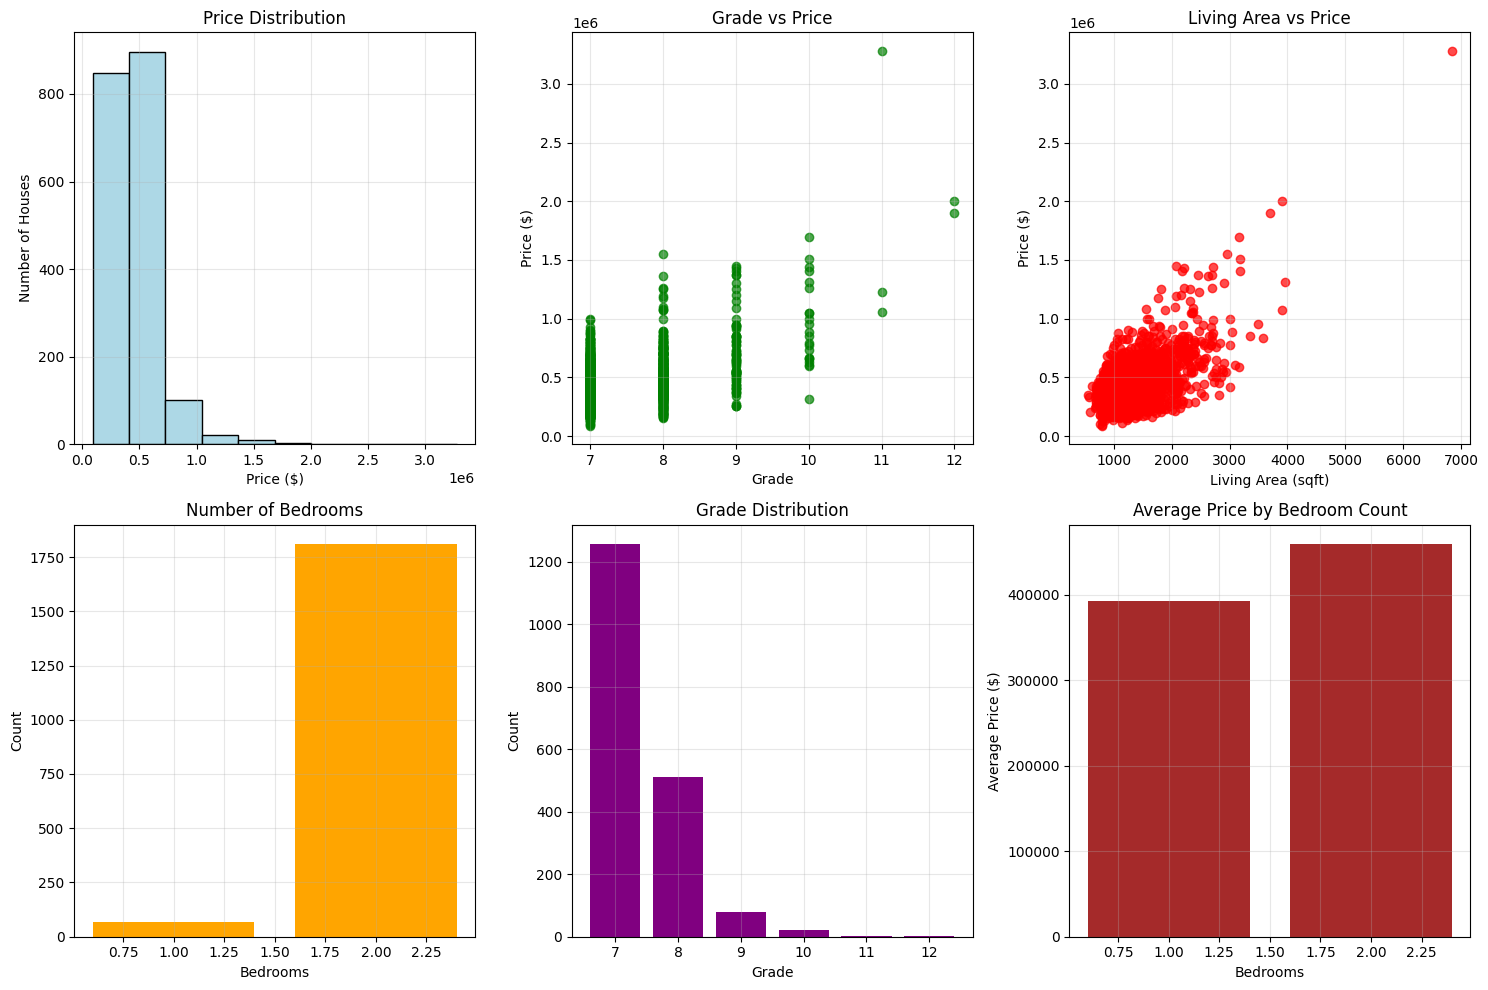


=== SUMMARY TABLE ===
      date       price  bedrooms  bathrooms  grade  sqft_living  yr_built
2014-05-13   90000.000     2.000      1.000      7      790.000      1973
2014-12-12   95000.000     2.000      1.000      7      800.000      1947
2014-07-17  100000.000     2.000      1.000      7      770.000      1978
2014-07-08  115000.000     1.000      2.000      7     1150.000      1962
2015-04-16  130000.000     2.000      1.000      7      790.000      1951
2014-10-21  130000.000     2.000      1.000      7      840.000      1951
2014-05-08  134000.000     2.000      1.500      7      980.000      1922
2015-03-24  139500.000     2.000      1.500      7     1230.000      1983
2015-02-17  149900.000     2.000      1.750      8     1090.000      1982
2015-03-24  150000.000     2.000      1.000      7     1250.000      1951
2014-05-22  150000.000     2.000      1.000      7      820.000      1954
2014-07-22  150000.000     2.000      1.500      7     1360.000      1978
2014-10-09  153

In [70]:
# Step 5: Create visualizations
print("\nCreating plots...")

# Create a figure with multiple plots
plt.figure(figsize=(15, 10))

# Create a figure with multiple plots
plt.figure(figsize=(15, 10))

# Plot 1: Price distribution
plt.subplot(2, 3, 1)
plt.hist(good_houses['price'], bins=10, color='lightblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Number of Houses')
plt.grid(True, alpha=0.3)

# Plot 2: Grade vs Price
plt.subplot(2, 3, 2)
plt.scatter(good_houses['grade'], good_houses['price'], color='green', alpha=0.7)
plt.title('Grade vs Price')
plt.xlabel('Grade')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)

# Plot 3: Living Area vs Price
plt.subplot(2, 3, 3)
plt.scatter(good_houses['sqft_living'], good_houses['price'], color='red', alpha=0.7)
plt.title('Living Area vs Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)

# Plot 4: Bedroom count
plt.subplot(2, 3, 4)
bedroom_counts = good_houses['bedrooms'].value_counts().sort_index()
plt.bar(bedroom_counts.index, bedroom_counts.values, color='orange')
plt.title('Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

# Plot 5: Grade distribution
plt.subplot(2, 3, 5)
grade_counts = good_houses['grade'].value_counts().sort_index()
plt.bar(grade_counts.index, grade_counts.values, color='purple')
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

# Plot 6: Price by bedroom count
plt.subplot(2, 3, 6)
price_by_bedrooms = good_houses.groupby('bedrooms')['price'].mean()
plt.bar(price_by_bedrooms.index, price_by_bedrooms.values, color='brown')
plt.title('Average Price by Bedroom Count')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 6: Simple summary table
print("\n=== SUMMARY TABLE ===")
summary = good_houses[['date', 'price', 'bedrooms', 'bathrooms', 'grade', 'sqft_living', 'yr_built']].copy()
summary = summary.sort_values('price')  # Sort by price (lowest first)
print(summary.to_string(index=False))

print(f"\n🎉 Analysis complete! Found {len(good_houses)} perfect matches for your criteria.")


In [71]:
check houses that are: 
1-2 BED ROOMS
grade - good to luxury
non renovated 

suburb home  = sq foot of neighbors and zipcode

sort list by price

SyntaxError: invalid syntax (3646329448.py, line 1)

In [75]:
print("=== 1-2 BEDROOM HOUSES WITH AVERAGE+ GRADE & NOT RENOVATED ===\n")

# Step 1: Filter for 1-2 bedrooms
one_two_bedrooms = df[(df['bedrooms'] >= 1) & (df['bedrooms'] <= 2)]
print(f"Step 1: Found {len(one_two_bedrooms)} houses with 1-2 bedrooms")

# Step 2: Filter for good or above grade (grade 8 or higher)
good_grade_houses = one_two_bedrooms[one_two_bedrooms['grade'] >= 8]
print(f"Step 2: Found {len(good_grade_houses)} houses with grade 8 or above")

# Step 3: Filter for NOT renovated (yr_renovated is 0 or NaN)
# In this dataset, 0.0 means not renovated, and NaN might also mean not renovated
not_renovated_houses = good_grade_houses[(good_grade_houses['yr_renovated'] == 0) | (good_grade_houses['yr_renovated'].isna())]
print(f"Step 3: Found {len(not_renovated_houses)} houses that are NOT renovated\n")


=== 1-2 BEDROOM HOUSES WITH AVERAGE+ GRADE & NOT RENOVATED ===

Step 1: Found 2956 houses with 1-2 bedrooms
Step 2: Found 620 houses with grade 8 or above
Step 3: Found 602 houses that are NOT renovated



In [76]:
print(not_renovated_houses.head(5))

          date       price          id  bedrooms  bathrooms  sqft_living  \
107 2014-07-23  188500.000  3530510041     2.000      1.750     1240.000   
218 2014-08-28 1070000.000  1250202145     2.000      2.250     3900.000   
219 2014-10-23  467000.000  7611200125     2.000      1.500     1320.000   
226 2015-03-09  479950.000  8682281200     2.000      2.000     1510.000   
438 2014-07-08  438000.000  9528102772     2.000      2.000     1270.000   

     sqft_lot  floors  waterfront  view  ...  yr_renovated  zipcode    lat  \
107  2493.000   1.000       0.000 0.000  ...         0.000    98198 47.381   
218 14864.000   1.000       0.000 3.000  ...         0.000    98144 47.588   
219 10800.000   1.000       0.000 0.000  ...         0.000    98177 47.715   
226  6516.000   1.000       0.000 0.000  ...         0.000    98053 47.708   
438  1372.000   3.000       0.000 0.000  ...         0.000    98115 47.678   

        long  sqft_living15  sqft_lot15         location  \
107 -122.322  

In [78]:
# Step 5: Show statistics
print("\n=== STATISTICS ===")
if len(not_renovated_houses) > 0:
    print(f"Total matching houses: {len(not_renovated_houses)}")
    print(f"Average price: ${not_renovated_houses['price'].mean():,.0f}")
    print(f"Minimum price: ${not_renovated_houses['price'].min():,.0f}")
    print(f"Maximum price: ${not_renovated_houses['price'].max():,.0f}")
    print(f"Average living area: {not_renovated_houses['sqft_living'].mean():.0f} sqft")
    print(f"Average grade: {not_renovated_houses['grade'].mean():.1f}")
    
    # Year built statistics
    print(f"Oldest house: {not_renovated_houses['yr_built'].min():.0f}")
    print(f"Newest house: {not_renovated_houses['yr_built'].max():.0f}")
    print(f"Average year built: {not_renovated_houses['yr_built'].mean():.0f}")
else:
    print("No statistics available - no matching houses found.")


=== STATISTICS ===
Total matching houses: 602
Average price: $541,941
Minimum price: $149,900
Maximum price: $3,280,000
Average living area: 1612 sqft
Average grade: 8.2
Oldest house: 1900
Newest house: 2015
Average year built: 1991



Creating plots...


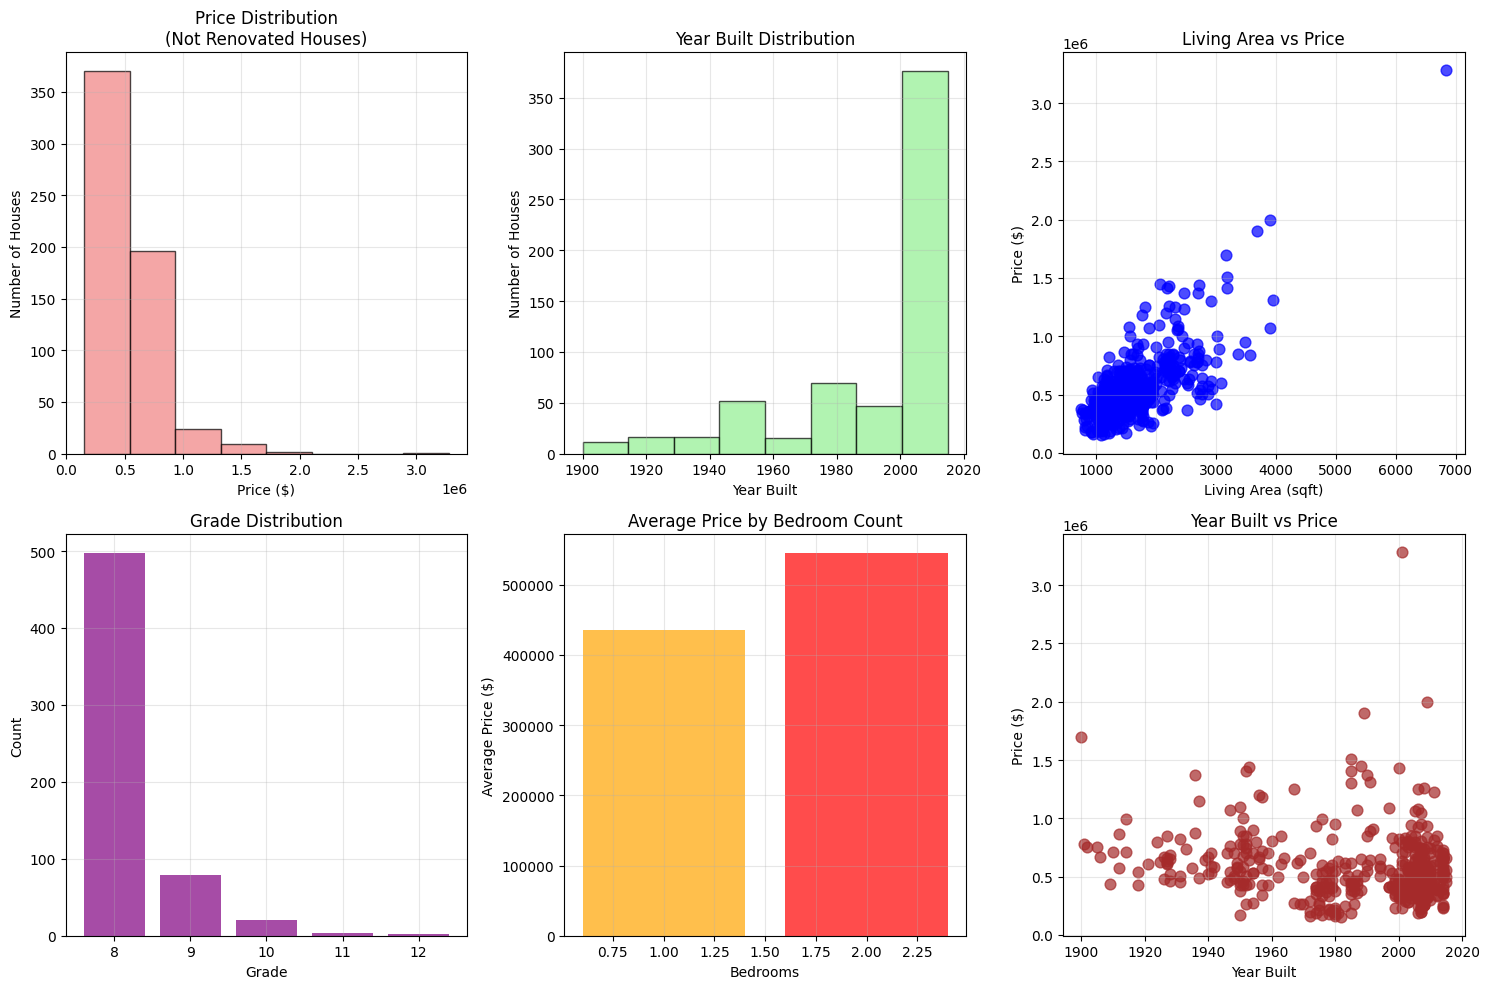


=== SUMMARY TABLE ===
      date       price  bedrooms  bathrooms  grade  sqft_living  yr_built  zipcode
2015-02-17  149900.000     2.000      1.750      8     1090.000      1982    98198
2015-04-27  160000.000     2.000      1.000      8     1140.000      1980    98028
2014-07-11  162950.000     2.000      1.000      8      950.000      1972    98198
2014-05-30  168000.000     2.000      1.500      8     1220.000      1976    98198
2014-06-04  170000.000     2.000      1.000      8     1500.000      1950    98168
2014-09-30  176000.000     2.000      1.000      8      920.000      1980    98198
2014-08-21  178500.000     2.000      1.000      8      930.000      1978    98198
2014-08-15  187000.000     2.000      1.750      8     1050.000      1974    98198
2014-07-23  188500.000     2.000      1.750      8     1240.000      1985    98198
2015-04-15  189950.000     2.000      1.000      8     1030.000      1981    98038
2014-08-01  190000.000     2.000      2.500      8     1100.000 

In [79]:
# Step 6: Create visualizations
if len(not_renovated_houses) > 0:
    print("\nCreating plots...")
    
    # Create a figure with multiple plots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Price distribution
    plt.subplot(2, 3, 1)
    plt.hist(not_renovated_houses['price'], bins=8, color='lightcoral', edgecolor='black', alpha=0.7)
    plt.title('Price Distribution\n(Not Renovated Houses)')
    plt.xlabel('Price ($)')
    plt.ylabel('Number of Houses')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Year built distribution
    plt.subplot(2, 3, 2)
    plt.hist(not_renovated_houses['yr_built'], bins=8, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.title('Year Built Distribution')
    plt.xlabel('Year Built')
    plt.ylabel('Number of Houses')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Living Area vs Price
    plt.subplot(2, 3, 3)
    plt.scatter(not_renovated_houses['sqft_living'], not_renovated_houses['price'], 
               color='blue', alpha=0.7, s=60)
    plt.title('Living Area vs Price')
    plt.xlabel('Living Area (sqft)')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Grade distribution
    plt.subplot(2, 3, 4)
    grade_counts = not_renovated_houses['grade'].value_counts().sort_index()
    plt.bar(grade_counts.index, grade_counts.values, color='purple', alpha=0.7)
    plt.title('Grade Distribution')
    plt.xlabel('Grade')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Price by bedroom count
    plt.subplot(2, 3, 5)
    price_by_bedrooms = not_renovated_houses.groupby('bedrooms')['price'].mean()
    colors = ['orange', 'red']
    plt.bar(price_by_bedrooms.index, price_by_bedrooms.values, color=colors[:len(price_by_bedrooms)], alpha=0.7)
    plt.title('Average Price by Bedroom Count')
    plt.xlabel('Bedrooms')
    plt.ylabel('Average Price ($)')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Year built vs Price
    plt.subplot(2, 3, 6)
    plt.scatter(not_renovated_houses['yr_built'], not_renovated_houses['price'], 
               color='brown', alpha=0.7, s=60)
    plt.title('Year Built vs Price')
    plt.xlabel('Year Built')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Step 7: Simple summary table
    print("\n=== SUMMARY TABLE ===")
    summary = not_renovated_houses[['date', 'price', 'bedrooms', 'bathrooms', 'grade', 
                                  'sqft_living', 'yr_built', 'zipcode']].copy()
    summary = summary.sort_values('price')  # Sort by price (lowest first)
    print(summary.to_string(index=False))
    
    print(f"\n✅ Analysis complete! Found {len(not_renovated_houses)} houses matching all criteria.")
else:
    print("\n❌ No houses found matching all criteria.")

# Additional: Show what criteria filtered out houses
print("\n=== FILTERING BREAKDOWN ===")
print(f"Total houses in dataset: {len(df)}")
print(f"After 1-2 bedroom filter: {len(one_two_bedrooms)}")
print(f"After grade 7+ filter: {len(good_grade_houses)}")
print(f"After not-renovated filter: {len(not_renovated_houses)}")


In [38]:
# Step 4: Create the map
print("\n Step 4: Creating the map...")

# Find the middle point of all houses for centering the map
middle_lat = df3['lat'].mean()
middle_long = df3['long'].mean()

# Create a basic map
house_map = folium.Map(location=[middle_lat, middle_long], zoom_start=10)


 Step 4: Creating the map...


In [40]:
# Step 5: Add house markers to the map
print("📌 Adding house markers to map...")

# Colors for different locations
colors = {
    "In Seattle City": "blue",
    "Outside Seattle": "red"
}

# Icons for different locations
icons = {
    "In Seattle City": "home",
    "Outside Seattle": "globe"
}

for index, house in df.iterrows():
    # Create a popup with house information
    popup_text = f"""
    <b>Location:</b> {house['location']}<br>
    <b>Price:</b> ${house['price']:,.0f}<br>
    <b>Zipcode:</b> {int(house['zipcode'])}<br>
    <b>Bedrooms:</b> {int(house['bedrooms'])}<br>
    <b>Bathrooms:</b> {house['bathrooms']}<br>
    <b>Size:</b> {int(house['sqft_living'])} sqft
    """
    
    # Add marker to map
    folium.Marker(
        location=[house['lat'], house['long']],
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"${house['price']:,.0f} - {house['location']}",
        icon=folium.Icon(
            color=colors[house['location']],
            icon=icons[house['location']],
            prefix='fa'
        )
    ).add_to(house_map)


📌 Adding house markers to map...


In [41]:
# Step 7: Add a legend to the map
print("📖 Adding legend...")

legend_html = '''
<div style="position: fixed; 
            top: 10px; left: 50px; width: 200px; 
            background: white; border: 2px solid grey; 
            padding: 10px; font-size: 14px; z-index: 9999;">
    <h4 style="margin: 0 0 8px 0;">House Locations</h4>
    <p style="margin: 2px 0;">
        <i class="fa fa-home" style="color: blue"></i> In Seattle City
    </p>
    <p style="margin: 2px 0;">
        <i class="fa fa-globe" style="color: red"></i> Outside Seattle
    </p>
</div>
'''

house_map.get_root().html.add_child(folium.Element(legend_html))

📖 Adding legend...


In [ ]:
# Step 8: Save the map
## This is a HUGE image with too many points
house_map.save("simple_house_locations.html")

# configure chrome
options = Options()
options.add_argument("--headless")
driver = webdriver.Chrome(options=options)

# load the html
driver.get("simple_house_locations.html")
time.sleep(3)   # wait for map tiles to load

# save screenshot
driver.save_screenshot("map.png")
driver.quit()
print("✅ Map saved as 'simple_house_locations.html'")


In [63]:
print("=== HOUSE SALES TIMING ANALYSIS ===\n")

# 1. Analyze by YEAR
print("1. SALES BY YEAR:")
yearly_sales = df['date'].dt.year.value_counts().sort_index()
for year, count in yearly_sales.items():
    percentage = (count / len(df)) * 100
    avg_price = df[df['date'].dt.year == year]['price'].mean()
    print(f"  {year}: {count} sales ({percentage:.1f}%) - Avg price: ${avg_price:,.0f}")

=== HOUSE SALES TIMING ANALYSIS ===

1. SALES BY YEAR:
  2014: 14622 sales (67.7%) - Avg price: $539,351
  2015: 6975 sales (32.3%) - Avg price: $542,279


**When are houses most sold**

In [82]:
print("=== MONTHLY HOUSE SALES ANALYSIS ===\n")

# Extract month and month name from date
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['year'] = df['date'].dt.year

# Monthly sales count
monthly_sales = df['month_name'].value_counts()

=== MONTHLY HOUSE SALES ANALYSIS ===



In [90]:
# Reorder months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)

print("HOUSE SALES BY MONTH:")
print("=" * 40)

total_sales = len(df)
for month in month_order:
    count = monthly_sales.get(month, 0)
    percentage = (count / total_sales) * 100
    print(f"{month:12}: {count:2} sales ({percentage:5.1f}%)")


# Seasonal analysis
print(f"\n🌤️  SEASONAL ANALYSIS:")
seasons = {
    'Winter (Dec-Feb)': [12, 1, 2],
    'Spring (Mar-May)': [3, 4, 5],
    'Summer (Jun-Aug)': [6, 7, 8],
    'Fall (Sep-Nov)': [9, 10, 11]
}

for season, months in seasons.items():
    season_sales = len(df[df['month'].isin(months)])
    percentage = (season_sales / total_sales) * 100
    print(f"{season:15}: {season_sales:2} sales ({percentage:5.1f}%) - Avg price: ${avg_price:,.0f}")


# Find the busiest month
busiest_month = monthly_sales.idxmax()
busiest_count = monthly_sales.max()
busiest_percentage = (busiest_count / total_sales) * 100

HOUSE SALES BY MONTH:
January     : 978 sales (  4.5%)
February    : 1247 sales (  5.8%)
March       : 1875 sales (  8.7%)
April       : 2229 sales ( 10.3%)
May         : 2414 sales ( 11.2%)
June        : 2178 sales ( 10.1%)
July        : 2211 sales ( 10.2%)
August      : 1939 sales (  9.0%)
September   : 1771 sales (  8.2%)
October     : 1876 sales (  8.7%)
November    : 1409 sales (  6.5%)
December    : 1470 sales (  6.8%)

🌤️  SEASONAL ANALYSIS:
Winter (Dec-Feb): 3695 sales ( 17.1%) - Avg price: $531,276
Spring (Mar-May): 6518 sales ( 30.2%) - Avg price: $531,276
Summer (Jun-Aug): 6328 sales ( 29.3%) - Avg price: $531,276
Fall (Sep-Nov) : 5056 sales ( 23.4%) - Avg price: $531,276


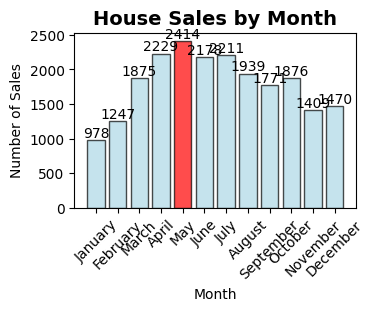

In [91]:
# Plot 1: Monthly sales bar chart
plt.subplot(2, 2, 1)
colors = ['lightblue' if month != busiest_month else 'red' for month in month_order]
bars = plt.bar(month_order, [monthly_sales.get(month, 0) for month in month_order], 
               color=colors, alpha=0.7, edgecolor='black')
plt.title('House Sales by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

Text(0.5, 1.0, 'Sales by Season')

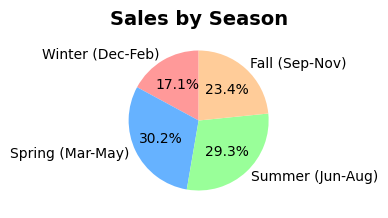

In [92]:
# Plot 2: Seasonal sales pie chart
plt.subplot(2, 2, 2)
seasonal_counts = [len(df[df['month'].isin(months)]) for season, months in seasons.items()]
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
plt.pie(seasonal_counts, labels=seasons.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Sales by Season', fontsize=14, fontweight='bold')

# Shortlisting houses

1. 1-2 bedrooms
2. county house: 
    a. best timing (Season; Mar- May)
    b. non renovated
3. city house
    a. central
    b. fast

**STEP 1: Filter for 1-2 bedrooms**

In [93]:
print("\nSTEP 1: Filtering for 1-2 bedrooms...")
bedroom_filter = df[(df['bedrooms'] >= 1) & (df['bedrooms'] <= 2)]
print(f"Found {len(bedroom_filter)} houses with 1-2 bedrooms")


STEP 1: Filtering for 1-2 bedrooms...
Found 2956 houses with 1-2 bedrooms


**STEP 2. Select houses in the country side / city**

In [94]:
df_bedroom = bedroom_filter.copy()

# Step 1: Analyze the zipcodes in your dataset
print("=== ZIPCODE ANALYSIS ===")
print("Unique zipcodes in dataset:")
print(df_bedroom['zipcode'].unique())
unique_zipcodes = sorted(df_bedroom['zipcode'].unique())
print(f"Unique zipcodes in your dataset: {unique_zipcodes}")
print(f"Number of properties: {len(df_bedroom)}")
print(f"Number of unique zipcodes: {len(unique_zipcodes)}")


# Check the geographic spread
print(f"\nGeographic range:")
print(f"Latitude: {df_bedroom['lat'].min():.4f} to {df_bedroom['lat'].max():.4f}")
print(f"Longitude: {df_bedroom['long'].min():.4f} to {df_bedroom['long'].max():.4f}")

# We need to understand the geographic distribution and identify which zipcodes correspond to the city center vs. suburban/rural areas.

# Count how many properties are in each zipcode and print them in order

## df['zipcode'] selects the zipcode column from the DataFrame.
## .value_counts() counts how many times each zipcode appears (i.e., how many properties exist in each zipcode).
## .sort_index() sorts the results by zipcode number (ascending order), instead of sorting by count.

zipcode_counts = df_bedroom['zipcode'].value_counts().sort_index()

print("\nProperties per zipcode:")
for z, c in zipcode_counts.items():
    print(f"{int(z)}: {c} properties")



=== ZIPCODE ANALYSIS ===
Unique zipcodes in dataset:
[98028 98115 98002 98030 98133 98117 98118 98056 98136 98198 98178 98125
 98119 98027 98177 98038 98166 98168 98144 98053 98024 98126 98103 98106
 98070 98006 98105 98146 98059 98014 98011 98122 98112 98116 98188 98004
 98092 98055 98199 98045 98155 98102 98065 98001 98042 98075 98109 98003
 98072 98023 98022 98108 98107 98058 98007 98052 98034 98010 98019 98033
 98077 98008 98032 98074 98148 98029 98040 98031 98039 98005]
Unique zipcodes in your dataset: [np.int64(98001), np.int64(98002), np.int64(98003), np.int64(98004), np.int64(98005), np.int64(98006), np.int64(98007), np.int64(98008), np.int64(98010), np.int64(98011), np.int64(98014), np.int64(98019), np.int64(98022), np.int64(98023), np.int64(98024), np.int64(98027), np.int64(98028), np.int64(98029), np.int64(98030), np.int64(98031), np.int64(98032), np.int64(98033), np.int64(98034), np.int64(98038), np.int64(98039), np.int64(98040), np.int64(98042), np.int64(98045), np.int64(9

In [98]:
# Step 2: Define Seattle city zipcodes based on your actual data
# From your dataset, I can see both Seattle (981xx) and suburban (980xx) zipcodes

# df3['zipcode'].unique()
## Extracts the zipcode column from df3.
## .unique() returns a NumPy array of all unique zipcodes in the dataset.
seattle_zipcodes = {z for z in df_bedroom['zipcode'].unique() if 98100 <= z <= 98199}
suburban_zipcodes = {z for z in df_bedroom['zipcode'].unique() if 98000 <= z <= 98099}

# Step 3: Classify each house as "In City" or "Outside City"
print("\n🏷️ Step 3: Classifying houses...")

def where_is_house(zipcode):
    """Simple function to check if a house is in Seattle or outside"""
    if zipcode in seattle_zipcodes:
        return "In Seattle City"
    else:
        return "Outside Seattle"
    
# Make a new dataframe so the original df_bedroom is NOT changed
df_bedroom_loc = df_bedroom.copy()

# Add the new 'location' column to the NEW dataframe
df_bedroom_loc['location'] = df_bedroom_loc['zipcode'].apply(where_is_house)

# Apply the classification to each row
df_bedroom_loc['location'] = df_bedroom_loc['zipcode'].apply(where_is_house)

# Count how many houses in each category
location_counts = df_bedroom_loc['location'].value_counts()
print("House locations:")
for location, count in location_counts.items():
    print(f"  {location}: {count} houses")



🏷️ Step 3: Classifying houses...
House locations:
  In Seattle City: 2160 houses
  Outside Seattle: 796 houses


In [99]:
print(df_bedroom_loc.head(5))

         date      price          id  bedrooms  bathrooms  sqft_living  \
2  2015-02-25 180000.000  5631500400     2.000      1.000      770.000   
11 2014-05-27 468000.000  9212900260     2.000      1.000     1160.000   
18 2014-12-05 189000.000    16000397     2.000      1.000     1200.000   
23 2014-05-16 252700.000  8091400200     2.000      1.500     1070.000   
31 2014-12-01 280000.000  2426039314     2.000      1.500     1190.000   

    sqft_lot  floors  waterfront  view  ...     long  sqft_living15  \
2  10000.000   1.000       0.000 0.000  ... -122.233       2720.000   
11  6000.000   1.000       0.000 0.000  ... -122.292       1330.000   
18  9850.000   1.000       0.000 0.000  ... -122.210       1060.000   
23  9643.000   1.000       0.000 0.000  ... -122.166       1220.000   
31  1265.000   3.000       0.000 0.000  ... -122.357       1390.000   

    sqft_lot15         location            price_category  grade_category  \
2     8062.000  Outside Seattle           Budget (<

In [108]:
# Separate houses based on location: Country or City

df_bedroom_country = df_bedroom_loc[df_bedroom_loc['location'] == "Outside Seattle"]
print(len(df_bedroom_country.index))

df_bedroom_city = df_bedroom_loc[df_bedroom_loc['location'] != "Outside Seattle"]
print(len(df_bedroom_city.index))

796
2160


In [109]:
print(df_bedroom_country.head(5))

          date      price          id  bedrooms  bathrooms  sqft_living  \
2   2015-02-25 180000.000  5631500400     2.000      1.000      770.000   
18  2014-12-05 189000.000    16000397     2.000      1.000     1200.000   
23  2014-05-16 252700.000  8091400200     2.000      1.500     1070.000   
88  2014-05-19 215000.000  1332700270     2.000      2.250     1610.000   
147 2014-08-06 430000.000  3224079105     2.000      2.500     2420.000   

     sqft_lot  floors  waterfront  view  ...     long  sqft_living15  \
2   10000.000   1.000       0.000 0.000  ... -122.233       2720.000   
18   9850.000   1.000       0.000 0.000  ... -122.210       1060.000   
23   9643.000   1.000       0.000 0.000  ... -122.166       1220.000   
88   2040.000   2.000       0.000 0.000  ... -122.194       1950.000   
147 60984.000   2.000       0.000 0.000  ... -121.943       1940.000   

     sqft_lot15         location            price_category  grade_category  \
2      8062.000  Outside Seattle      

In [113]:
# Step 2a: Find houses sold in March, April, or May
print("\nStep 1: Finding houses sold in Spring months...")

# for county houses
## Select houses sold in Spring (Mar-May)
## Select houses that are non renovated

# Make a new dataframe so the original df_bedroom is NOT changed
df_bdrm_cntry_time = df_bedroom_country.copy()

# Spring months: March=3, April=4, May=5
spring_months = [3, 4, 5]
spring_houses = df_bdrm_cntry_time[df_bdrm_cntry_time['month'].isin(spring_months)]

print(f"Found {len(spring_houses)} houses sold in March, April, or May")

Found 247 houses sold in March, April, or May


In [114]:
# Step 2b: Find houses that were NOT renovated
print("\nStep 2: Finding houses that were NOT renovated...")

# We are considering a house is not renovated if renovation year is 0; 
# Missing can be no info available, or not renovated
non_renovated_houses = spring_houses[(spring_houses['yr_renovated'] == 0) #| (spring_houses['yr_renovated'].isna())
                                     ]

print(f"Found {len(non_renovated_houses)} houses that were not renovated")



Step 2: Finding houses that were NOT renovated...
Found 233 houses that were not renovated


In [141]:
# SIMPLE STATISTICS
print("\n" + "=" * 40)
print("QUICK STATS")
print("=" * 40)

if len(non_renovated_houses) > 0:
    avg_price = non_renovated_houses['price'].mean()
    min_price = non_renovated_houses['price'].min()
    max_price = non_renovated_houses['price'].max()
    
    print(f"Average price: ${avg_price:,.0f}")
    print(f"Cheapest: ${min_price:,.0f}")
    print(f"Most expensive: ${max_price:,.0f}")

# Count by month
march_count = len(non_renovated_houses[non_renovated_houses['month'] == 3])
april_count = len(non_renovated_houses[non_renovated_houses['month'] == 4])
may_count = len(non_renovated_houses[non_renovated_houses['month'] == 5])
    
print(f"\nSold in March: {march_count} houses")
print(f"Sold in April: {april_count} houses")
print(f"Sold in May: {may_count} houses")

# SUMMARY
print("\n" + "=" * 60)
if len(non_renovated_houses) > 0:
    print(f"🎉 Found {len(non_renovated_houses)} perfect matches!")
else:
    print("No houses found matching your criteria.")
print("=" * 60)


QUICK STATS
Average price: $386,060
Cheapest: $80,000
Most expensive: $2,000,000

Sold in March: 64 houses
Sold in April: 76 houses
Sold in May: 93 houses

🎉 Found 233 perfect matches!


In [142]:
print(non_renovated_houses.head(5))

          date      price          id  bedrooms  bathrooms  sqft_living  \
23  2014-05-16 252700.000  8091400200     2.000      1.500     1070.000   
88  2014-05-19 215000.000  1332700270     2.000      2.250     1610.000   
226 2015-03-09 479950.000  8682281200     2.000      2.000     1510.000   
395 2015-04-30 330000.000  3649100320     2.000      1.000     1220.000   
465 2014-05-23  80000.000  8658300340     1.000      0.750      430.000   

     sqft_lot  floors  waterfront  view  ...     long  sqft_living15  \
23   9643.000   1.000       0.000 0.000  ... -122.166       1220.000   
88   2040.000   2.000       0.000 0.000  ... -122.194       1950.000   
226  6516.000   1.000       0.000 0.000  ... -122.013       1640.000   
395 10000.000   1.000       0.000 0.000  ... -122.241       2000.000   
465  5050.000   1.000       0.000 0.000  ... -121.909       1200.000   

     sqft_lot15         location            price_category  grade_category  \
23     8386.000  Outside Seattle  Affo

In [125]:
list(non_renovated_houses.columns.values)
list(non_renovated_houses)

['date',
 'price',
 'id',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'location',
 'price_category',
 'grade_category',
 'bedroom_category',
 'month',
 'month_name',
 'year']

In [126]:
# get price_category and grade 

price_category = non_renovated_houses['price_category'].unique()
print(price_category)

grade_category = non_renovated_houses['grade_category'].unique()
print(grade_category)


['Affordable ($250K-$400K)', 'Budget (<$250K)', 'Mid-Range ($400K-$600K)', 'Premium ($600K-$1M)', 'Luxury (>$1M)']
Categories (5, object): ['Budget (<$250K)' < 'Affordable ($250K-$400K)' < 'Mid-Range ($400K-$600K)' < 'Premium ($600K-$1M)' < 'Luxury (>$1M)']
['Average' 'Good' 'Below Average' 'Excellent' 'Very Good' 'Luxury']


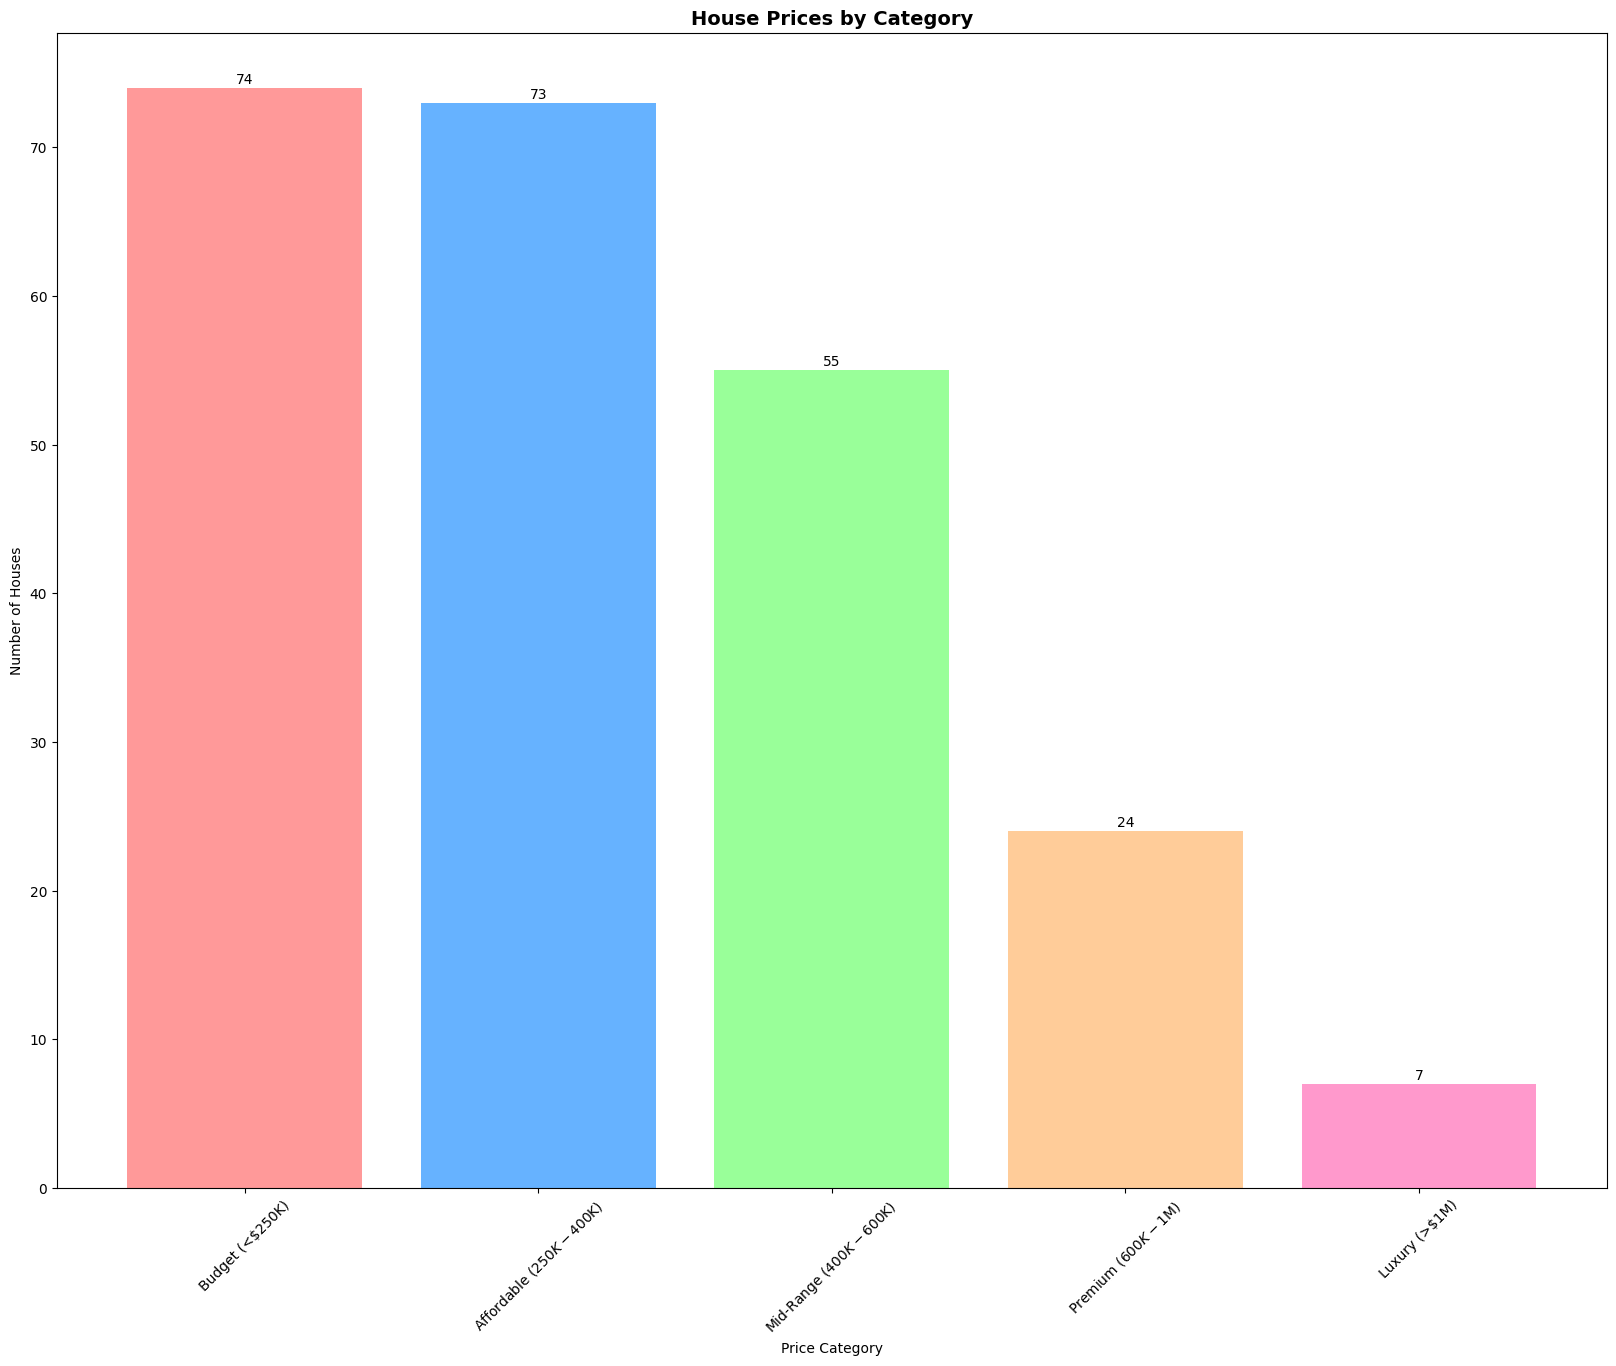

In [128]:
# Create a big figure with all our plots
plt.figure(figsize=(20, 15))

# Plot 1: Bar Chart - Price Categories
#plt.subplot(2, 3, 1)
price_counts = non_renovated_houses['price_category'].value_counts()
colors1 = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
plt.bar(price_counts.index, price_counts.values, color=colors1)
plt.title('House Prices by Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on top of bars
for i, count in enumerate(price_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')


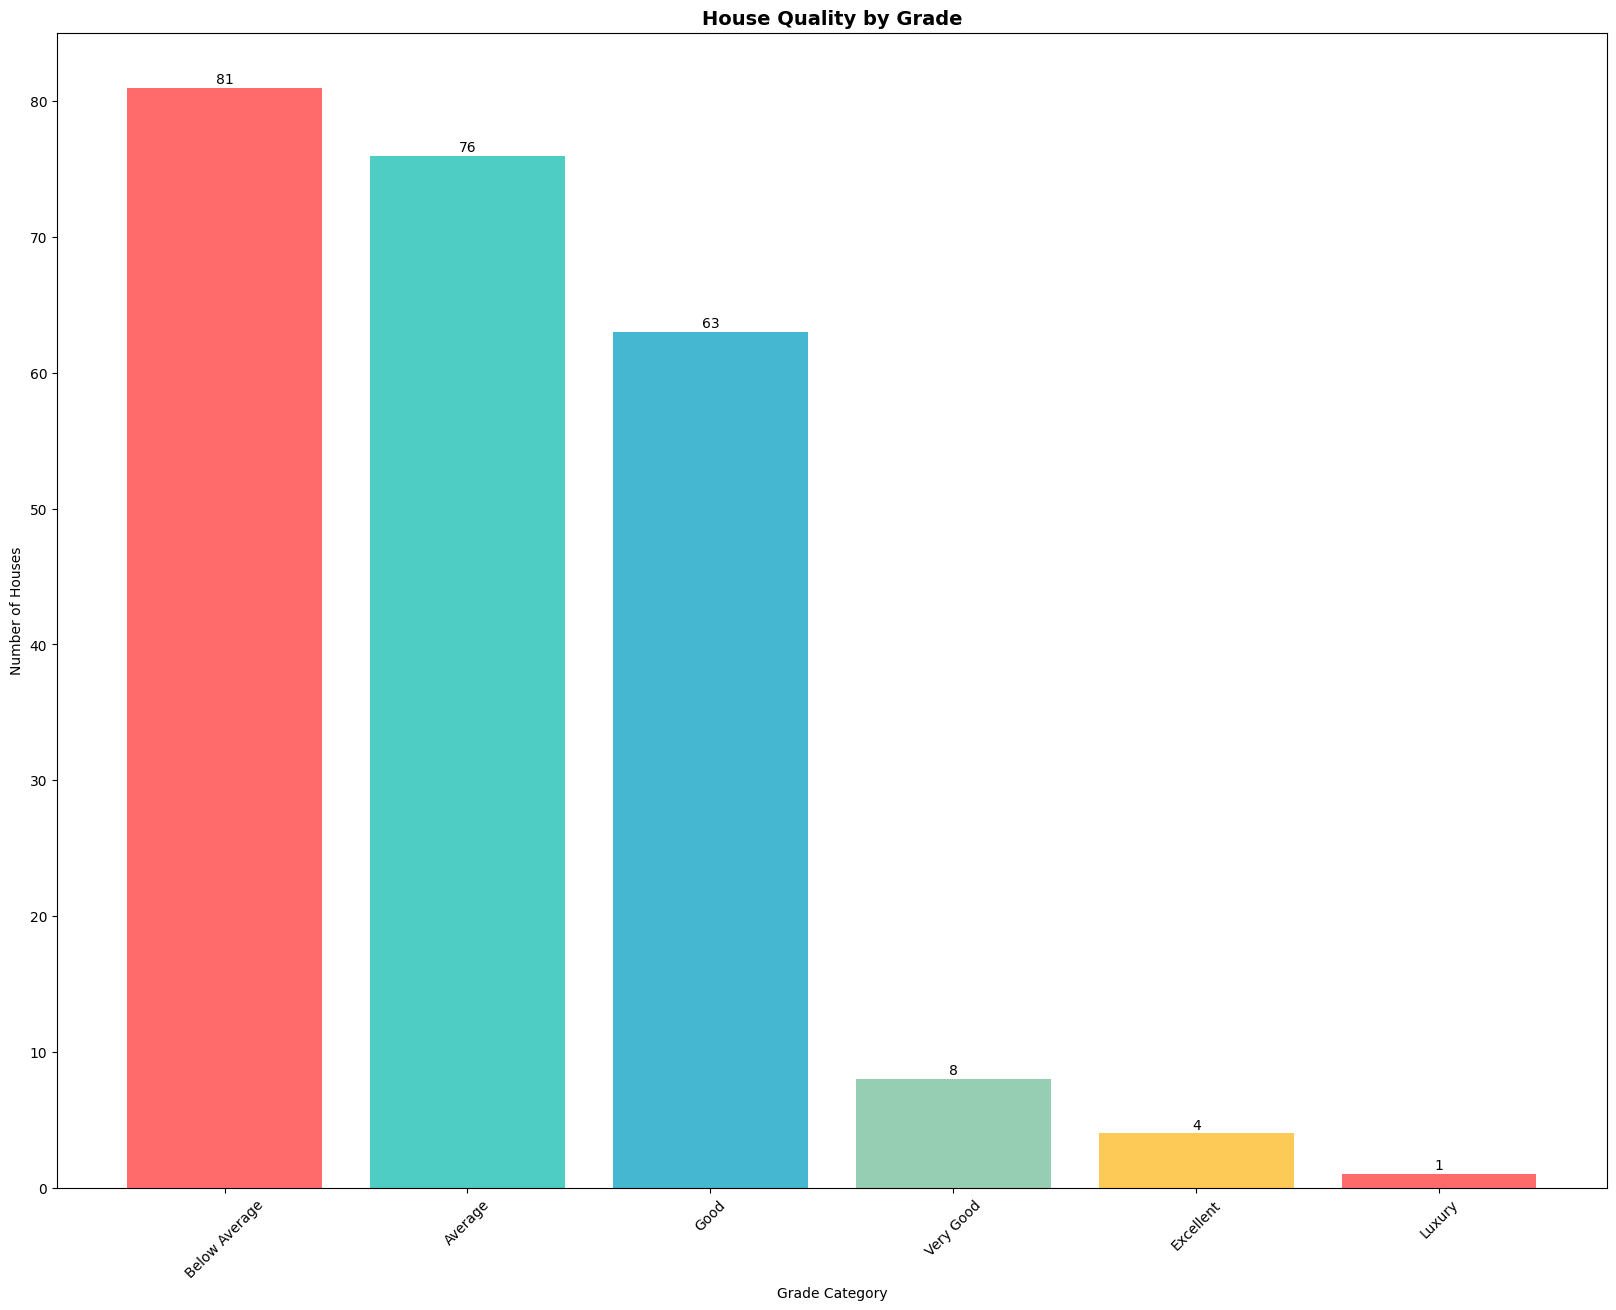

In [129]:
# Create a big figure with all our plots
plt.figure(figsize=(20, 15))

# Plot 2: Bar Chart - Grade Categories
grade_counts =  non_renovated_houses['grade_category'].value_counts()
colors2 = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']
plt.bar(grade_counts.index, grade_counts.values, color=colors2)
plt.title('House Quality by Grade', fontsize=14, fontweight='bold')
plt.xlabel('Grade Category')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on top of bars
for i, count in enumerate(grade_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')


In [143]:
print(non_renovated_houses.head(10))

          date      price          id  bedrooms  bathrooms  sqft_living  \
23  2014-05-16 252700.000  8091400200     2.000      1.500     1070.000   
88  2014-05-19 215000.000  1332700270     2.000      2.250     1610.000   
226 2015-03-09 479950.000  8682281200     2.000      2.000     1510.000   
395 2015-04-30 330000.000  3649100320     2.000      1.000     1220.000   
465 2014-05-23  80000.000  8658300340     1.000      0.750      430.000   
531 2015-05-05 200000.000  1843200240     2.000      1.500     1360.000   
817 2015-05-13 250000.000  1922059135     2.000      2.000     1130.000   
837 2015-05-13 419950.000  8682262400     2.000      1.750     1350.000   
981 2015-03-10 420000.000  7853340860     2.000      2.750     1760.000   
997 2015-04-15 189950.000  1442800370     2.000      1.000     1030.000   

     sqft_lot  floors  waterfront  view  ...     long  sqft_living15  \
23   9643.000   1.000       0.000 0.000  ... -122.166       1220.000   
88   2040.000   2.000       0.

In [ ]:
## THIS DOES NOT WORK
    ## column values do not match the strings you're filtering for.
## BUT your code is filtering the column grade, not grade_category.
## Correct Fix: You must filter using grade_category and price_category, not the raw columns.

#df_country_selected = non_renovated_houses[
#    (non_renovated_houses['grade'].isin(['Average', 'Good', 'Very Good'])) &
#    (non_renovated_houses['price'].isin(['Budget','Affordable', 'Mid-Range', 'Premium']))
#]
#print(f"Found {len(df_country_selected)} houses matching your criteria!")

In [148]:
## We have selected houses that are:
    ## With Grade: Good, Very Good and Excellent & Price Budget, Affordable, there were no houses

df_country_selected = non_renovated_houses[
    (non_renovated_houses['grade_category'].isin(['Good', 'Very Good'])) &
    (non_renovated_houses['price_category'].isin([
        'Affordable ($250K-$400K)',
        'Mid-Range ($400K-$600K)'
    ]))
]

print(f"Found {len(df_country_selected)} houses matching your criteria!")

Found 50 houses matching your criteria!


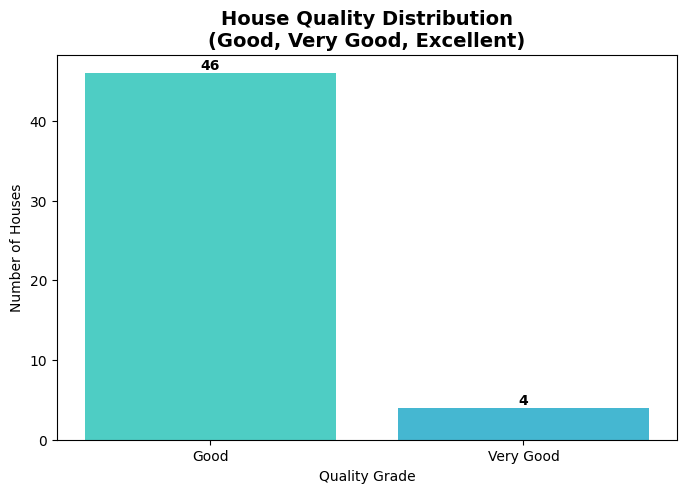

In [149]:
#plt.subplot(2, 3, 1)
grade_counts = df_country_selected['grade_category'].value_counts()
colors = ['#4ECDC4', '#45B7D1', '#96CEB4']  # Green-blue colors for quality
plt.bar(grade_counts.index, grade_counts.values, color=colors)
plt.title('House Quality Distribution\n(Good, Very Good, Excellent)', fontsize=14, fontweight='bold')
plt.xlabel('Quality Grade')
plt.ylabel('Number of Houses')
    # Add numbers on bars
for i, count in enumerate(grade_counts.values):
        plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')

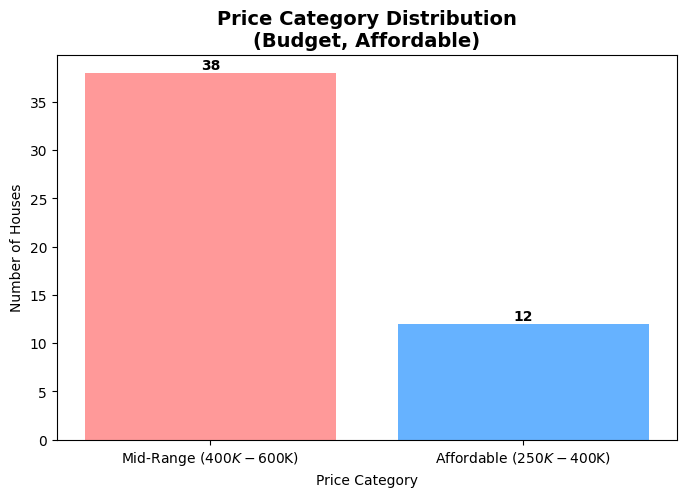

In [152]:
 #Chart 2: Bar Chart - Count by Price Category
 
price_counts = df_country_selected['price_category'].value_counts()
# remove entries where count == 0
price_counts = price_counts[price_counts > 0]

colors = ['#FF9999', '#66B2FF']  # Red-blue colors for price
plt.bar(price_counts.index, price_counts.values, color=colors)
plt.title('Price Category Distribution\n(Budget, Affordable)', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Number of Houses')
    # Add numbers on bars
for i, count in enumerate(price_counts.values):
        plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')

Text(0.5, 1.0, 'Quality vs Price Combination')

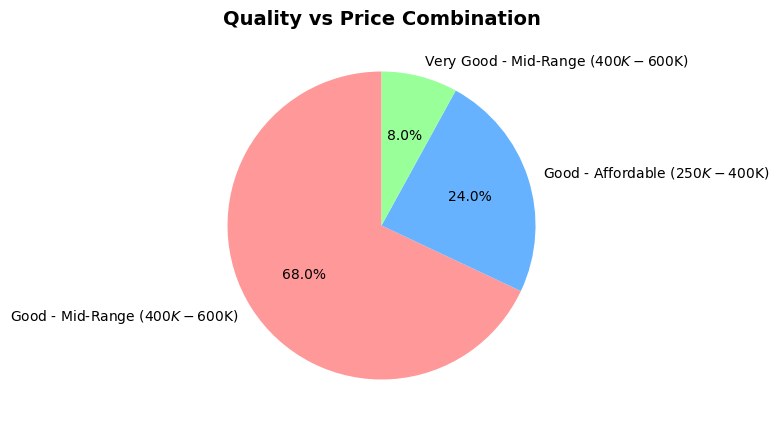

In [154]:
# Chart 3: Pie Chart - Grade vs Price Combination

df_country_selected['grade_price'] = (
    df_country_selected['grade_category'].astype(str)
    + ' - ' +
    df_country_selected['price_category'].astype(str)
)

combo_counts = df_country_selected['grade_price'].value_counts()



combo_counts = df_country_selected['grade_price'].value_counts()
colors_pie = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#C9C9FF']
plt.pie(combo_counts.values, labels=combo_counts.index, autopct='%1.1f%%', 
            colors=colors_pie[:len(combo_counts)], startangle=90)
plt.title('Quality vs Price Combination', fontsize=14, fontweight='bold')


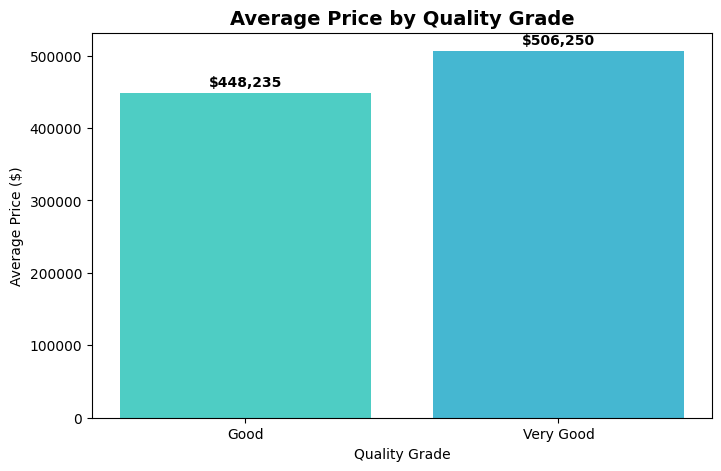

In [155]:
# Chart 4: Bar Chart - Average Price by Grade

avg_price_by_grade = df_country_selected.groupby('grade_category')['price'].mean()
colors_avg = ['#4ECDC4', '#45B7D1', '#96CEB4']
plt.bar(avg_price_by_grade.index, avg_price_by_grade.values, color=colors_avg)
plt.title('Average Price by Quality Grade', fontsize=14, fontweight='bold')
plt.xlabel('Quality Grade')
plt.ylabel('Average Price ($)')
    # Add values on bars
for i, price in enumerate(avg_price_by_grade.values):
        plt.text(i, price + 5000, f'${price:,.0f}', ha='center', va='bottom', fontweight='bold')

**County house further narrowed down**

#This is based on:
1. Waterfront
2. View
3. Year built


In [156]:
df_country_premium = df_country_selected[
    (df_country_selected['grade_category'].isin(['Good'])) &
    (df_country_selected['price_category'].isin([
        'Affordable ($250K-$400K)'
    ]))
]

print(f"Found {len(df_country_premium)} houses matching your criteria!")

Found 12 houses matching your criteria!


In [158]:
print(df_country_premium.head(5))

           date      price          id  bedrooms  bathrooms  sqft_living  \
2434 2015-04-02 360000.000  2597710070     2.000      2.000     1770.000   
2485 2014-05-02 335000.000  7525100520     2.000      2.000     1350.000   
6815 2015-03-26 347000.000  3582750280     2.000      1.750     1315.000   
7015 2015-03-23 330000.000  4223400050     2.000      1.500     1440.000   
7520 2015-04-07 376000.000  3629960590     2.000      2.000     1340.000   

      sqft_lot  floors  waterfront  view  ...  sqft_living15  sqft_lot15  \
2434  7607.000   1.000       0.000 0.000  ...       2090.000    7109.000   
2485  2560.000   1.000       0.000 0.000  ...       1790.000    2560.000   
6815  2162.000   2.000       0.000 0.000  ...       1640.000    2128.000   
7015 11954.000   1.000       0.000 0.000  ...       1460.000    9730.000   
7520  1635.000   2.000       0.000 0.000  ...       1410.000    1375.000   

             location            price_category  grade_category  \
2434  Outside Seatt

In [161]:
waterfront = df_country_premium['waterfront'].unique()
print(waterfront)

view = df_country_premium['view'].unique()
print(view)

yr_built = df_country_premium['year'].unique()
print(yr_built)

[0.]
[0.]
[2015 2014]


In [ ]:
top_city_houses = df_country_premium[
    df_country_premium['year'] ==2015]

print(f"Found {len(top_city_houses)} houses matching your criteria!")

Found 11 houses matching your criteria!


In [ ]:
print("Creating Charts for Houses by Bedrooms, Living Area, and Price")
print("=" * 60)

# Step 1: Load the data
top_city_houses['price'] = pd.to_numeric(df_country_2015['price'], errors='coerce')
# Here we only have 2 bedrooms, so we leave out the following query
#df_country_2015['bedrooms'] = pd.to_numeric(df_country_2015['bedrooms'], errors='coerce')
df_country_2015['sqft_living15'] = pd.to_numeric(df_country_2015['sqft_living15'], errors='coerce')

print(f"Loaded {len(df_country_2015)} df_country_2015")
#print(f"Bedrooms range: {df_country_2015['bedrooms'].min()} to {df_country_2015['bedrooms'].max()}")
print(f"Living area range: {df_country_2015['sqft_living15'].min()} to {df_country_2015['sqft_living15'].max()} sqft")
print(f"Price range: ${df_country_2015['price'].min():,} to ${df_country_2015['price'].max():,}")


Creating Charts for Houses by Bedrooms, Living Area, and Price
Loaded 11 df_country_2015
Bedrooms range: 2.0 to 2.0
Living area range: 1310.0 to 2370.0 sqft
Price range: $255,000.0 to $395,000.0


In [177]:
# Step 2: Create categories for sqft_living15
def get_living_area_category(sqft):
    if sqft < 1000:
        return "Small (<1000 sqft)"
    elif sqft < 1500:
        return "Medium (1000-1500 sqft)"
    elif sqft < 2000:
        return "Large (1500-2000 sqft)"
    elif sqft < 2500:
        return "Extra Large (2000-2500 sqft)"
    else:
        return "Huge (>2500 sqft)"

df_country_2015['living_area_category'] = df_country_2015['sqft_living15'].apply(get_living_area_category)

print(f"\nCreated categories for {len(df_country_2015)} houses")
print("Living Area Categories:", df_country_2015['living_area_category'].unique())


Created categories for 11 houses
Living Area Categories: ['Extra Large (2000-2500 sqft)' 'Large (1500-2000 sqft)'
 'Medium (1000-1500 sqft)']


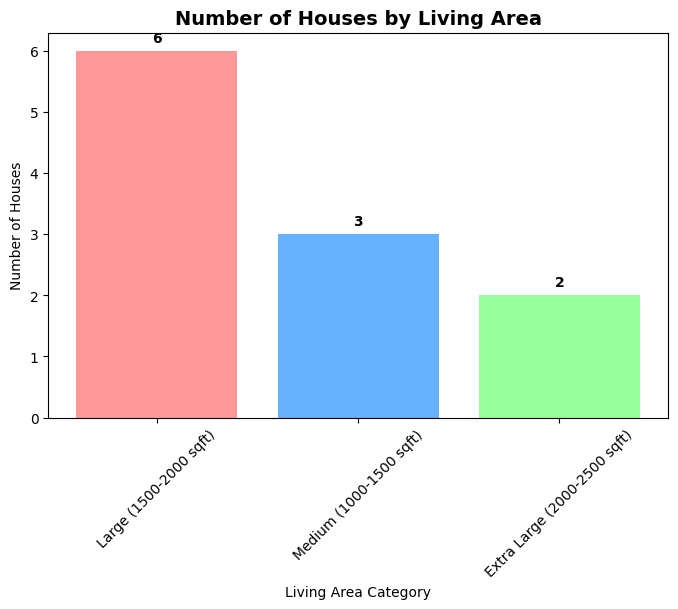

In [178]:
# Chart: Bar Chart - Number of houses by living area category

area_counts = df_country_2015['living_area_category'].value_counts()
colors2 = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
plt.bar(area_counts.index, area_counts.values, color=colors2)
plt.title('Number of Houses by Living Area', fontsize=14, fontweight='bold')
plt.xlabel('Living Area Category')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on bars
for i, count in enumerate(area_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')

In [198]:

# Map center
middle_lat = df_country_2015['lat'].mean()
middle_long = df_country_2015['long'].mean()

map_houses = folium.Map(location=[middle_lat, middle_long], zoom_start=10, tiles='cartodb positron')

# Set bounds
bounds = [
    [df_country_2015['lat'].min(), df_country_2015['long'].min()],
    [df_country_2015['lat'].max(), df_country_2015['long'].max()]
]
map_houses.fit_bounds(bounds)

# Marker cluster for better visualization
marker_cluster = MarkerCluster().add_to(map_houses)

def get_marker_color(price_category):
    color_map = {
        'Budget (<$250K)': 'green',
        'Affordable ($250K-$400K)': 'blue', 
        'Mid-Range ($400K-$600K)': 'orange',
        'Premium ($600K-$1M)': 'purple',
        'Luxury (>$1M)': 'red'
    }
    return color_map.get(price_category, 'gray')

# Add markers
for _, row in df_country_2015.iterrows():
    popup_content = f"""
    <div style="width: 250px;">
        <h4>🏠 House Details</h4>
        <hr>
        <b>Price:</b> ${row['price']:,.0f}<br>
        <b>Bedrooms:</b> {row['bedrooms']}<br>
        <b>Bathrooms:</b> {row['bathrooms']}<br>
        <b>Living Area:</b> {row['sqft_living']} sqft<br>
        <b>Grade:</b> {row.get('grade_category', row.get('grade', 'N/A'))}<br>
        <b>Price Category:</b> {row.get('price_category', 'N/A')}<br>
        <b>Year Built:</b> {row['yr_built']}<br>
        <b>Renovated:</b> {'No' if pd.isna(row['yr_renovated']) or row['yr_renovated']==0 else 'Yes'}
    </div>
    """
    price_cat = row.get('price_category', 'Unknown')
    marker_color = get_marker_color(price_cat)

    folium.Marker(
        location=[row['lat'], row['long']],
        tooltip=f"${row['price']:,.0f} | {row['bedrooms']} bed | Grade: {row.get('grade_category', row.get('grade', 'N/A'))}",
        popup=folium.Popup(popup_content, max_width=300),
        icon=folium.Icon(color=marker_color, icon='home')
    ).add_to(marker_cluster)

print(f"✅ Added {len(df_country_2015)} house markers")

# Add legend
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 180px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px">
     <p><strong>🏠 Price Legend</strong></p>
     <p><span style="color: green;">●</span> Budget (<$250K)</p>
     <p><span style="color: blue;">●</span> Affordable ($250K-$400K)</p>
     <p><span style="color: orange;">●</span> Mid-Range ($400K-$600K)</p>
     <p><span style="color: purple;">●</span> Premium ($600K-$1M)</p>
     <p><span style="color: red;">●</span> Luxury (>$1M)</p>
</div>
'''
map_houses.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_houses.save("country_house_locations.html")
print("✅ Map saved as 'country_house_locations.html'")


✅ Added 11 house markers
✅ Map saved as 'country_house_locations.html'


**Selecting city house**

In [204]:
print(df_bedroom_city.head(5))

print(df_bedroom_city.columns)

         date      price          id  bedrooms  bathrooms  sqft_living  \
11 2014-05-27 468000.000  9212900260     2.000      1.000     1160.000   
31 2014-12-01 280000.000  2426039314     2.000      1.500     1190.000   
53 2015-02-05 585000.000  3626039271     2.000      1.750     1980.000   
82 2014-10-28 355000.000  9418400240     2.000      1.000     2020.000   
89 2014-09-04 335000.000  3869900162     2.000      1.750     1030.000   

    sqft_lot  floors  waterfront  view  ...     long  sqft_living15  \
11  6000.000   1.000       0.000 0.000  ... -122.292       1330.000   
31  1265.000   3.000       0.000 0.000  ... -122.357       1390.000   
53  8550.000   1.000       0.000 0.000  ... -122.369       1480.000   
82  6720.000   1.000       0.000 0.000  ... -122.291       1720.000   
89  1066.000   2.000       0.000 0.000  ... -122.387       1030.000   

    sqft_lot15         location            price_category  grade_category  \
11    6000.000  In Seattle City   Mid-Range ($400K-

In [208]:
# === Classify city center or outskirts (based on zipcodes)===

print("🏙️ ANALYZING ZIPCODES FOR CITY AREA CLASSIFICATION")
print("=" * 60)

# Step 1: Check what zipcodes we have
print("📊 ZIPCODE ANALYSIS:")
unique_zipcodes = sorted(df_bedroom_city['zipcode'].unique())
print(f"Total unique zipcodes: {len(unique_zipcodes)}")
print(f"Zipcode range: {min(unique_zipcodes)} to {max(unique_zipcodes)}")


🏙️ ANALYZING ZIPCODES FOR CITY AREA CLASSIFICATION
📊 ZIPCODE ANALYSIS:
Total unique zipcodes: 29
Zipcode range: 98102 to 98199


In [210]:
# Step 2: Count houses per zipcode
print(f"\n🏠 HOUSES PER ZIPCODE:")
zipcode_counts = df_bedroom_city['zipcode'].value_counts().sort_index()
print(f"Top 20 zipcodes by house count:")
for zipcode, count in zipcode_counts.head(20).items():
    print(f"  {zipcode}: {count} houses")


🏠 HOUSES PER ZIPCODE:
Top 20 zipcodes by house count:
  98102: 23 houses
  98103: 176 houses
  98105: 42 houses
  98106: 92 houses
  98107: 86 houses
  98108: 45 houses
  98109: 22 houses
  98112: 47 houses
  98115: 141 houses
  98116: 78 houses
  98117: 165 houses
  98118: 144 houses
  98119: 41 houses
  98122: 72 houses
  98125: 77 houses
  98126: 135 houses
  98133: 111 houses
  98136: 87 houses
  98144: 91 houses
  98146: 69 houses


In [211]:
# Step 3: Analyze price by zipcode
print(f"\n💰 PRICE ANALYSIS BY ZIPCODE:")
zipcode_prices = df_bedroom_city.groupby('zipcode')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Top 10 most expensive zipcodes:")
for i, (zipcode, data) in enumerate(zipcode_prices.head(10).iterrows()):
    print(f"  {i+1:2}. {zipcode}: ${data['mean']:,.0f} ({data['count']} houses)")

print("\nTop 10 cheapest zipcodes:")
for i, (zipcode, data) in enumerate(zipcode_prices.tail(10).iterrows()):
    print(f"  {i+1:2}. {zipcode}: ${data['mean']:,.0f} ({data['count']} houses)")


💰 PRICE ANALYSIS BY ZIPCODE:
Top 10 most expensive zipcodes:
   1. 98109: $653,086 (22.0 houses)
   2. 98119: $615,175 (41.0 houses)
   3. 98112: $612,548 (47.0 houses)
   4. 98105: $543,949 (42.0 houses)
   5. 98199: $539,872 (68.0 houses)
   6. 98102: $534,685 (23.0 houses)
   7. 98116: $491,958 (78.0 houses)
   8. 98107: $487,356 (86.0 houses)
   9. 98103: $478,797 (176.0 houses)
  10. 98177: $475,885 (30.0 houses)

Top 10 cheapest zipcodes:
   1. 98133: $322,169 (111.0 houses)
   2. 98155: $316,217 (74.0 houses)
   3. 98146: $307,561 (69.0 houses)
   4. 98108: $302,734 (45.0 houses)
   5. 98106: $266,366 (92.0 houses)
   6. 98178: $257,292 (53.0 houses)
   7. 98148: $234,400 (8.0 houses)
   8. 98188: $231,617 (18.0 houses)
   9. 98198: $228,713 (52.0 houses)
  10. 98168: $201,574 (85.0 houses)


In [213]:
# Step 4: Create city area categories based on zipcode patterns
# Common Seattle area classification (you can adjust these)
def classify_city_area(zipcode):
    """Classify zipcodes into city areas based on known Seattle patterns"""
    
    # Downtown/Core urban areas
    downtown_zipcodes = [98101, 98104, 98121, 98122, 98134]
    
    # Central neighborhoods close to downtown
    central_zipcodes = [
        98102, 98103, 98105, 98107, 98108, 98109, 98112, 98115, 
        98116, 98117, 98118, 98119, 98125, 98126, 98133, 98136,
        98144, 98146, 98148, 98168, 98177, 98178, 98188, 98198, 98199
    ]

    # North Seattle areas
    north_zipcodes = [98125, 98133, 98155, 98177]
    
    # South Seattle areas  
    south_zipcodes = [98108, 98118, 98126, 98136, 98144, 98146, 98148, 98168, 98178, 98188, 98198]
    
    # Eastside suburbs (across Lake Washington)
    eastside_zipcodes = [98004, 98005, 98006, 98007, 98008, 98033, 98034, 98039, 98052, 98053, 98074]
    
    # Other suburbs and outskirts
    other_suburbs = [98001, 98002, 98003, 98010, 98011, 98014, 98019, 98022, 98023, 
                    98024, 98027, 98028, 98029, 98030, 98031, 98032, 98038, 98040, 
                    98042, 98045, 98055, 98056, 98058, 98059, 98065, 98070, 98072, 
                    98075, 98077, 98092]
    
    if zipcode in downtown_zipcodes:
        return "Downtown/Core"
    elif zipcode in central_zipcodes:
        return "Central City"
    elif zipcode in north_zipcodes:
        return "North Seattle"
    elif zipcode in south_zipcodes:
        return "South Seattle"
    elif zipcode in eastside_zipcodes:
        return "Eastside Suburbs"
    elif zipcode in other_suburbs:
        return "Outer Suburbs"
    else:
        return "Other Areas"

# Apply the classification
df_bedroom_city['city_area'] = df_bedroom_city['zipcode'].apply(classify_city_area)

print(f"\n📍 CITY AREA CLASSIFICATION CREATED!")
print(f"Area categories: {df_bedroom_city['city_area'].unique()}")




📍 CITY AREA CLASSIFICATION CREATED!
Area categories: ['Central City' 'Other Areas' 'Downtown/Core' 'North Seattle']


In [ ]:
# Step 5: Analyze each city area
print(f"\n📈 ANALYSIS BY CITY AREA:")
area_stats = df_bedroom_city.groupby('city_area').agg({
    'price': ['count', 'mean', 'median'],
    'sqft_living': 'mean',
    'grade': 'mean',
    'bedrooms': 'mean'
}).round(2)

print(area_stats)


📈 ANALYSIS BY CITY AREA:
              price                       sqft_living grade bedrooms
              count       mean     median        mean  mean     mean
city_area                                                           
Central City   1894 409766.430 395000.000    1169.260 6.820    1.940
Downtown/Core    72 474937.140 437500.000    1144.490 7.430    1.900
North Seattle    74 316216.800 300000.000    1061.620 6.390    1.990
Other Areas     120 287908.360 261750.000    1027.410 6.450    1.890



📊 CREATING CITY AREA VISUALIZATIONS...


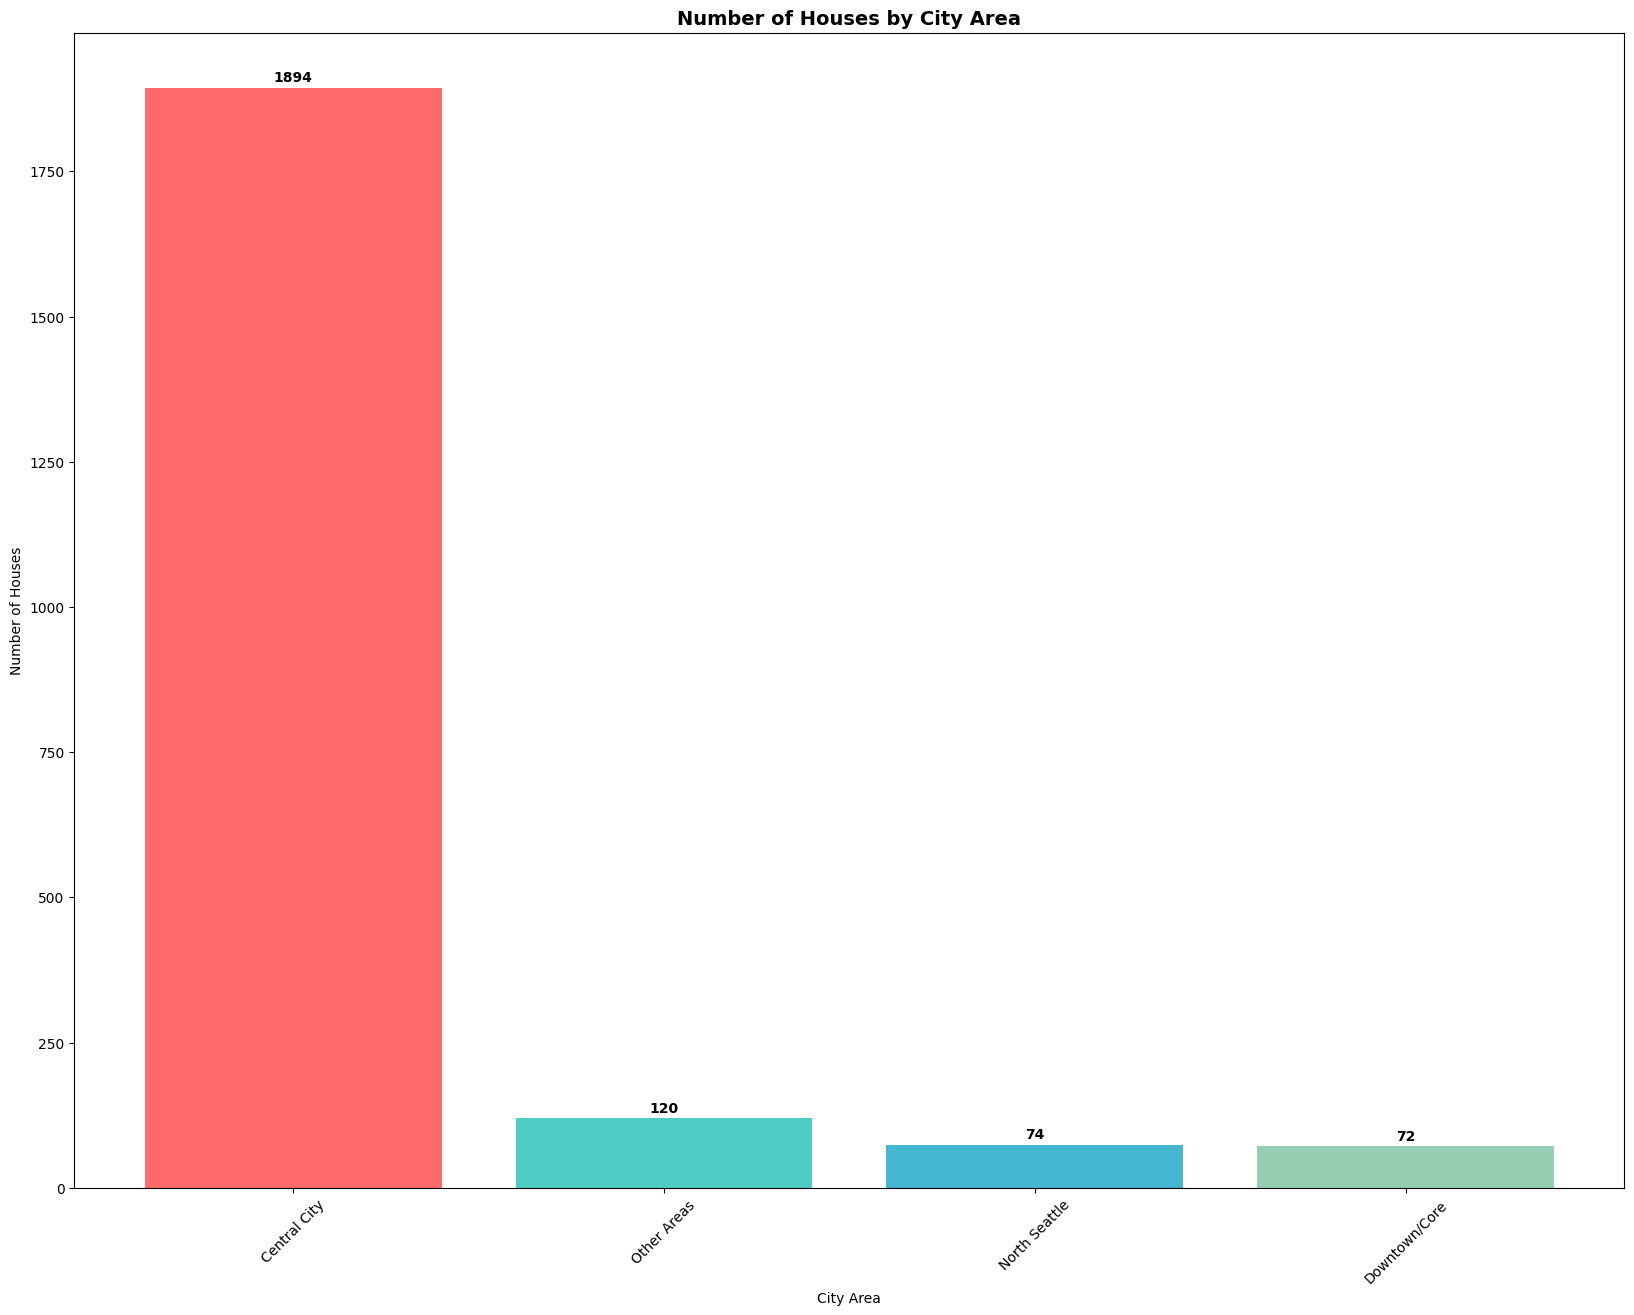

In [215]:
# Step 6: Create visualizations
print(f"\n📊 CREATING CITY AREA VISUALIZATIONS...")

plt.figure(figsize=(20, 15))

# Chart 1: Number of houses by city area
#plt.subplot(3, 4, 1)
area_counts = df_bedroom_city['city_area'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
plt.bar(area_counts.index, area_counts.values, color=colors[:len(area_counts)])
plt.title('Number of Houses by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on bars
for i, count in enumerate(area_counts.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold')

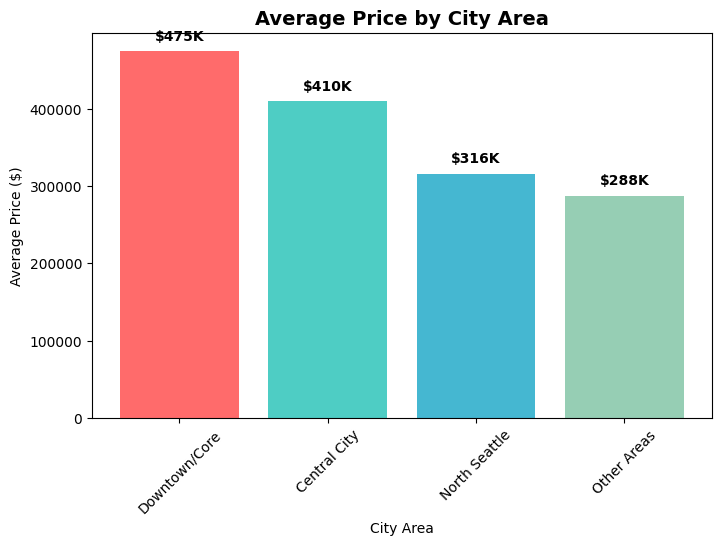

In [216]:
# Chart 2: Average price by city area
#plt.subplot(3, 4, 2)
area_prices = df_bedroom_city.groupby('city_area')['price'].mean().sort_values(ascending=False)
plt.bar(area_prices.index, area_prices.values, color=colors[:len(area_prices)])
plt.title('Average Price by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
# Add values on bars
for i, price in enumerate(area_prices.values):
    plt.text(i, price + 10000, f'${price/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

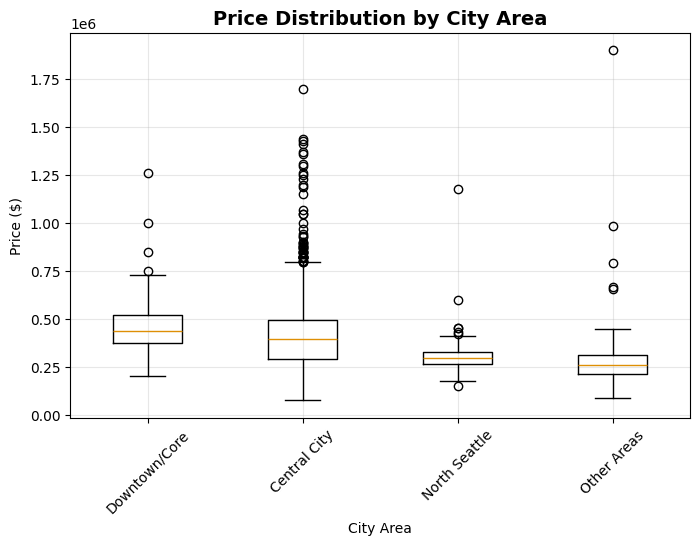

In [217]:
# Chart 3: Price distribution by city area (box plot)
#plt.subplot(3, 4, 3)
area_data = [df_bedroom_city[df_bedroom_city['city_area'] == area]['price'] for area in area_prices.index]
plt.boxplot(area_data, labels=area_prices.index)
plt.title('Price Distribution by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

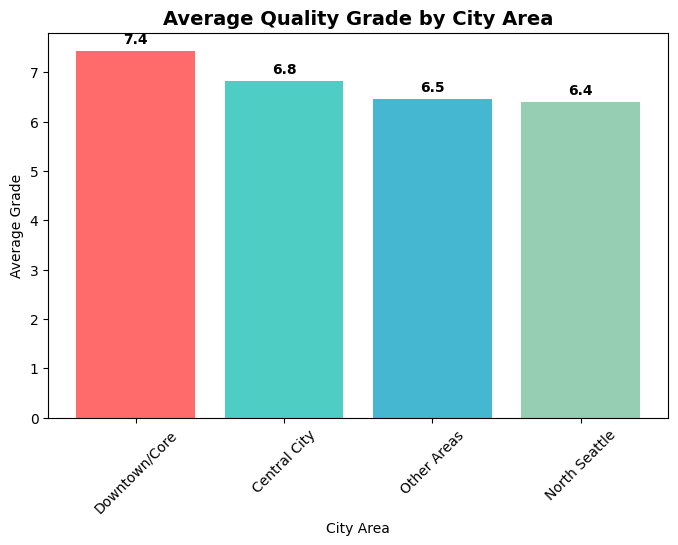

In [218]:
# Chart 5: Quality grade by city area
#plt.subplot(3, 4, 5)
area_grade = df_bedroom_city.groupby('city_area')['grade'].mean().sort_values(ascending=False)
plt.bar(area_grade.index, area_grade.values, color=colors[:len(area_grade)])
plt.title('Average Quality Grade by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Average Grade')
plt.xticks(rotation=45)
# Add values on bars
for i, grade in enumerate(area_grade.values):
    plt.text(i, grade + 0.1, f'{grade:.1f}', ha='center', va='bottom', fontweight='bold')

Text(0.5, 1.0, 'City Area Distribution')

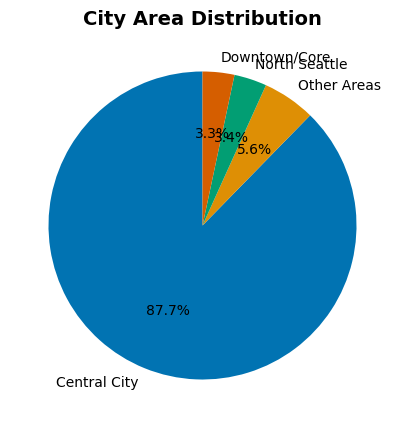

In [219]:
# Chart 6: Pie chart of city area distribution
#plt.subplot(3, 4, 8)
plt.pie(area_counts.values, labels=area_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('City Area Distribution', fontsize=14, fontweight='bold')

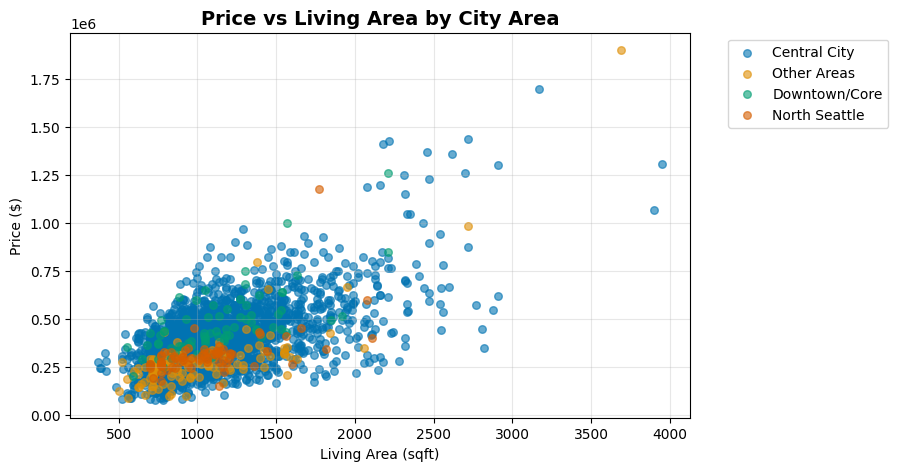

In [220]:
# Chart 9: Scatter plot - Price vs Living Area colored by city area
#plt.subplot(3, 4, 9)
for area in df_bedroom_city['city_area'].unique():
    subset = df_bedroom_city[df_bedroom_city['city_area'] == area]
    plt.scatter(subset['sqft_living'], subset['price'], alpha=0.6, label=area, s=30)
plt.title('Price vs Living Area by City Area', fontsize=14, fontweight='bold')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

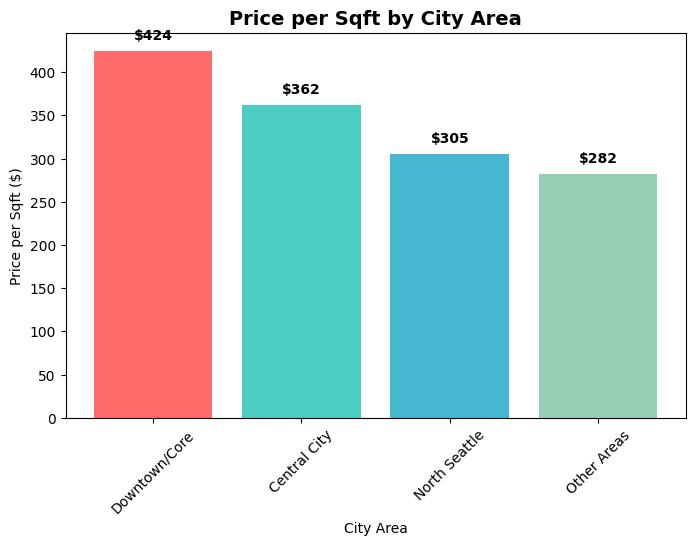

In [223]:
# Chart 6: Price per sqft by city area
#plt.subplot(3, 4, 6)
df_bedroom_city['price_per_sqft'] = df_bedroom_city['price'] /df_bedroom_city['sqft_living']
area_pps = df_bedroom_city.groupby('city_area')['price_per_sqft'].mean().sort_values(ascending=False)
plt.bar(area_pps.index, area_pps.values, color=colors[:len(area_pps)])
plt.title('Price per Sqft by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Price per Sqft ($)')
plt.xticks(rotation=45)
# Add values on bars
for i, pps in enumerate(area_pps.values):
    plt.text(i, pps + 10, f'${pps:.0f}', ha='center', va='bottom', fontweight='bold')

In [225]:
# Step 7: Show best value areas
print(f"\n💎 BEST VALUE ANALYSIS:")
print("Areas with good balance of price and quality:")

# Calculate value score (higher grade, lower price per sqft)
area_value = df_bedroom_city.groupby('city_area').agg({
    'price_per_sqft': 'mean',
    'grade': 'mean',
    'price': 'count'
}).round(2)

# Normalize for value score (lower price per sqft and higher grade is better)
area_value['price_per_sqft_norm'] = 1 - (area_value['price_per_sqft'] / area_value['price_per_sqft'].max())
area_value['grade_norm'] = area_value['grade'] / area_value['grade'].max()
area_value['value_score'] = (area_value['price_per_sqft_norm'] + area_value['grade_norm']) / 2

area_value = area_value.sort_values('value_score', ascending=False)
print(area_value[['price_per_sqft', 'grade', 'value_score']])


💎 BEST VALUE ANALYSIS:
Areas with good balance of price and quality:
               price_per_sqft  grade  value_score
city_area                                        
Other Areas           281.740  6.450        0.602
North Seattle         304.760  6.390        0.571
Central City          362.320  6.820        0.532
Downtown/Core         424.330  7.430        0.500


In [227]:
print(f"\n" + "=" * 60)
print("✅ CITY AREA ANALYSIS COMPLETE!")
print(f"• Created {len(df_bedroom_city['city_area'].unique())} city area categories")
print(f"• Analyzed {len(df_bedroom_city)} houses across all areas")
print(f"• Best value area: {area_value.index[0]} (score: {area_value['value_score'].iloc[0]:.3f})")
print("=" * 60)


✅ CITY AREA ANALYSIS COMPLETE!
• Created 4 city area categories
• Analyzed 2160 houses across all areas
• Best value area: Other Areas (score: 0.602)


In [232]:
print(df_bedroom_city.head(2))

         date      price          id  bedrooms  bathrooms  sqft_living  \
11 2014-05-27 468000.000  9212900260     2.000      1.000     1160.000   
31 2014-12-01 280000.000  2426039314     2.000      1.500     1190.000   

    sqft_lot  floors  waterfront  view  ...  sqft_lot15         location  \
11  6000.000   1.000       0.000 0.000  ...    6000.000  In Seattle City   
31  1265.000   3.000       0.000 0.000  ...    1756.000  In Seattle City   

              price_category  grade_category  bedroom_category  month  \
11   Mid-Range ($400K-$600K)         Average        Medium (3)      5   
31  Affordable ($250K-$400K)         Average        Medium (3)     12   

    month_name  year     city_area  price_per_sqft  
11         May  2014  Central City         403.448  
31    December  2014  Central City         235.294  

[2 rows x 30 columns]


In [233]:
## We have selected houses that are located in central Seattle because of 
    # Connectivity
    # The grade is 6.8

df_cc = df_bedroom_city[
    (df_bedroom_city['city_area'].isin(['Central City']))]

print(f"Found {len(df_cc)} houses matching your criteria!")


Found 1894 houses matching your criteria!


In [ ]:
# Some criterias to decide on the house:

# Price categories and value assessment
#- Price range: $280K-$468K (Mid-range to Affordable)
#- Price per sqft: $235-$403
#- Price category classification
#- Value for money assessment

In [236]:
print("🏠 PLOTTING HOUSES ACROSS ALL PRICE RANGES")
print("=" * 50)

# Step 1: Show distribution of all price categories
print("💰 PRICE CATEGORY DISTRIBUTION:")
price_distribution = df_cc['price_category'].value_counts()
total_houses = len(df_cc)

for category, count in price_distribution.items():
    percentage = (count / total_houses) * 100
    print(f"  {category}: {count} houses ({percentage:.1f}%)")

print(f"\n📊 TOTAL HOUSES: {total_houses}")

🏠 PLOTTING HOUSES ACROSS ALL PRICE RANGES
💰 PRICE CATEGORY DISTRIBUTION:
  Mid-Range ($400K-$600K): 721 houses (38.1%)
  Affordable ($250K-$400K): 663 houses (35.0%)
  Budget (<$250K): 306 houses (16.2%)
  Premium ($600K-$1M): 186 houses (9.8%)
  Luxury (>$1M): 18 houses (1.0%)

📊 TOTAL HOUSES: 1894


In [239]:
# Step 2: Basic statistics for each price category
print(f"\n📈 STATISTICS BY PRICE CATEGORY:")
category_stats = df_cc.groupby('price_category').agg({
    'price': ['count', 'mean', 'min', 'max'],
    'sqft_living': 'mean',
    'bedrooms': 'mean',
    'grade': 'mean'
}).round(2)

# Format the statistics table
category_stats.columns = ['Count', 'Avg_Price', 'Min_Price', 'Max_Price', 'Avg_Living_Area', 'Avg_Bedrooms', 'Avg_Grade']
print(category_stats)


📈 STATISTICS BY PRICE CATEGORY:
                          Count   Avg_Price   Min_Price   Max_Price  \
price_category                                                        
Budget (<$250K)             306  193541.300   78000.000  249900.000   
Affordable ($250K-$400K)    663  328826.230  250000.000  399950.000   
Mid-Range ($400K-$600K)     721  479648.780  400000.000  599950.000   
Premium ($600K-$1M)         186  700351.750  600000.000  970000.000   
Luxury (>$1M)                18 1265000.000 1000000.000 1700000.000   

                          Avg_Living_Area  Avg_Bedrooms  Avg_Grade  
price_category                                                      
Budget (<$250K)                   941.400         1.890      6.220  
Affordable ($250K-$400K)         1040.170         1.910      6.630  
Mid-Range ($400K-$600K)          1236.330         1.970      7.020  
Premium ($600K-$1M)              1603.220         1.970      7.480  
Luxury (>$1M)                    2626.670         2.000


📊 CREATING COMPREHENSIVE PLOTS FOR ALL PRICE RANGES...


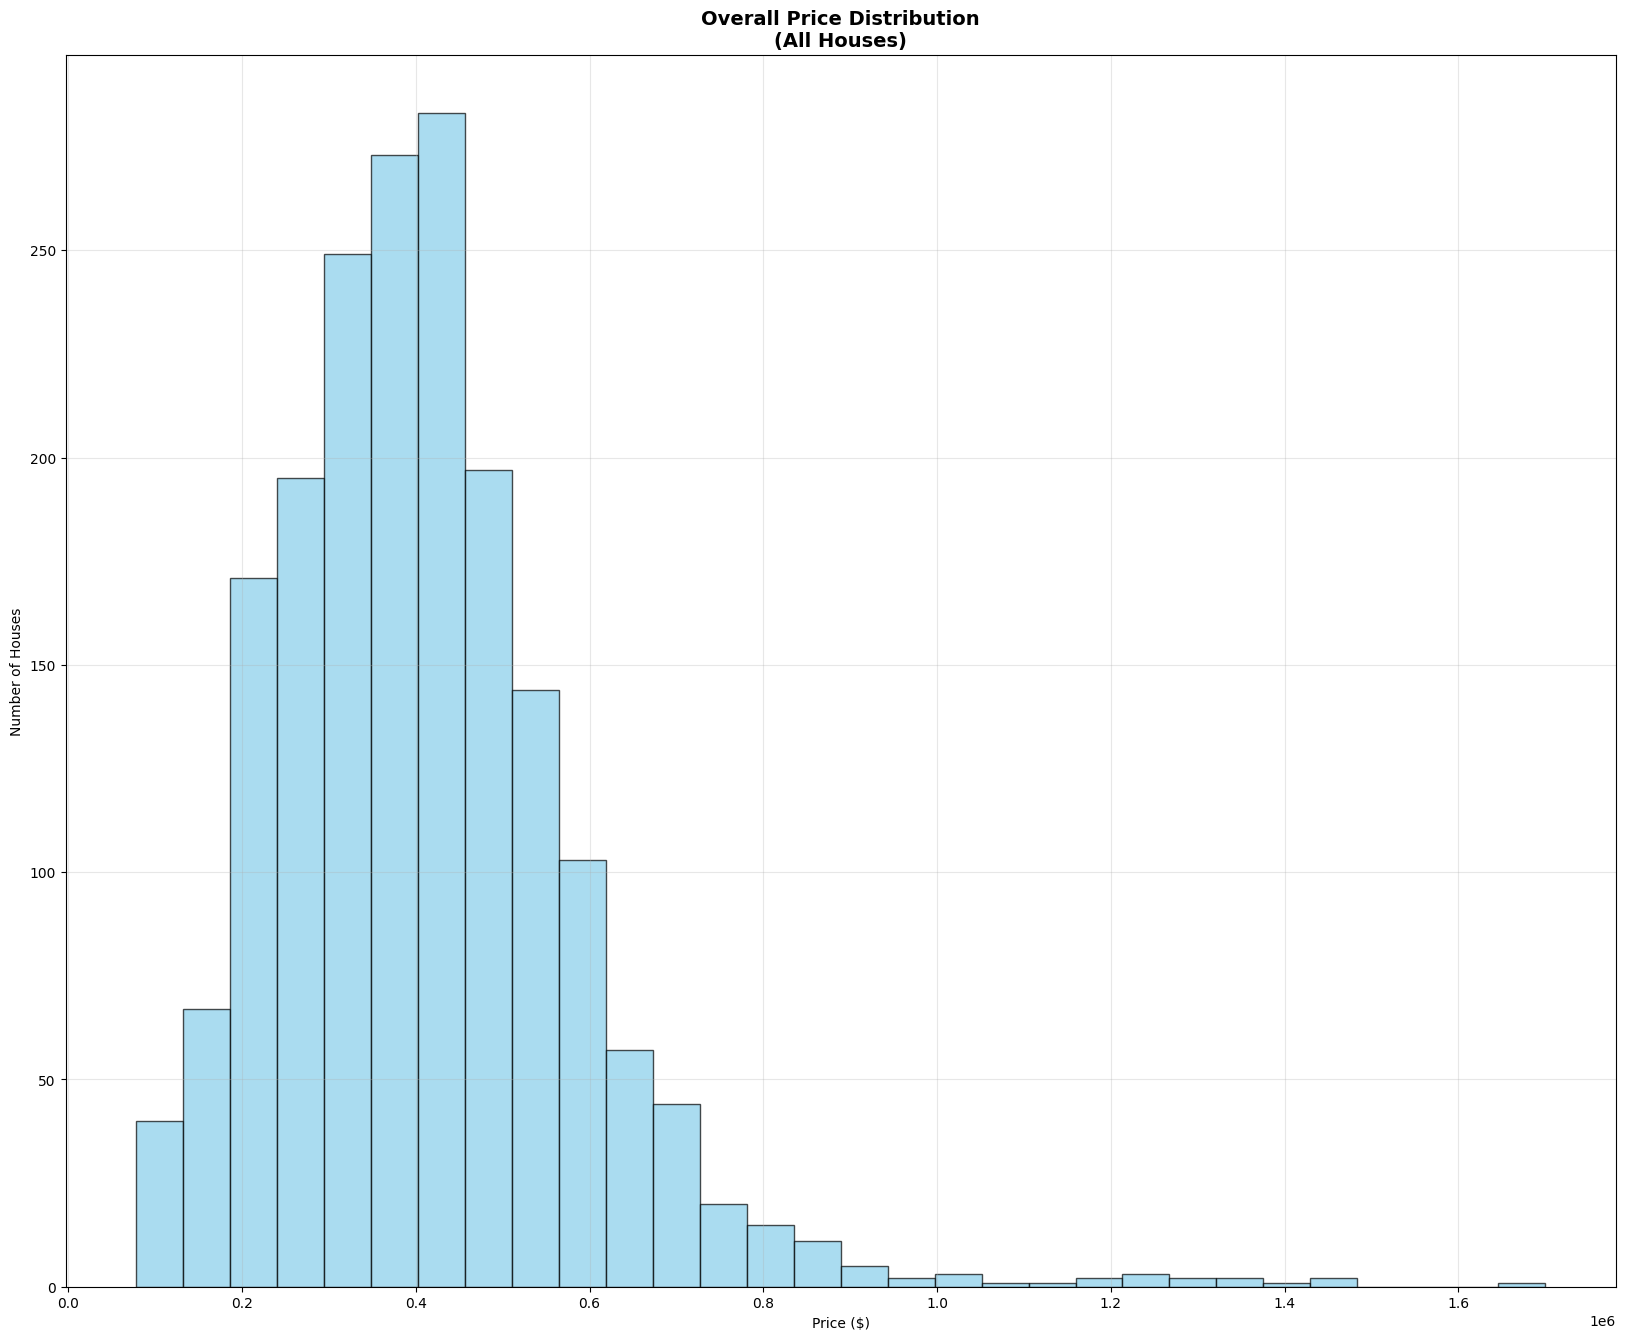

In [241]:
# Step 3: Create comprehensive visualizations for ALL price ranges
print(f"\n📊 CREATING COMPREHENSIVE PLOTS FOR ALL PRICE RANGES...")

plt.figure(figsize=(20, 16))

# Define colors for each price category
price_colors = {
    'Budget (<$250K)': '#FF6B6B',
    'Affordable ($250K-$400K)': '#4ECDC4',
    'Mid-Range ($400K-$600K)': '#45B7D1',
    'Premium ($600K-$1M)': '#96CEB4',
    'Luxury (>$1M)': '#FECA57'
}

# Chart 1: Price distribution histogram
#plt.subplot(3, 4, 1)
plt.hist(df_cc['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Overall Price Distribution\n(All Houses)', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Number of Houses')
plt.grid(True, alpha=0.3)

Text(0.5, 1.0, 'Price Category Distribution')

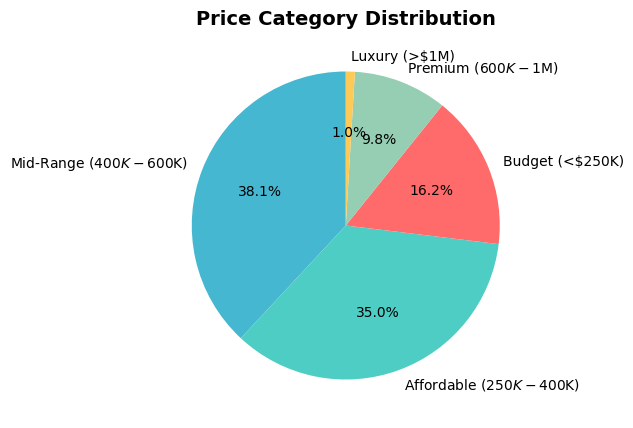

In [242]:
# Chart 2: Price categories pie chart
#plt.subplot(3, 4, 2)
plt.pie(price_distribution.values, labels=price_distribution.index, 
        autopct='%1.1f%%', startangle=90, colors=[price_colors[cat] for cat in price_distribution.index])
plt.title('Price Category Distribution', fontsize=14, fontweight='bold')


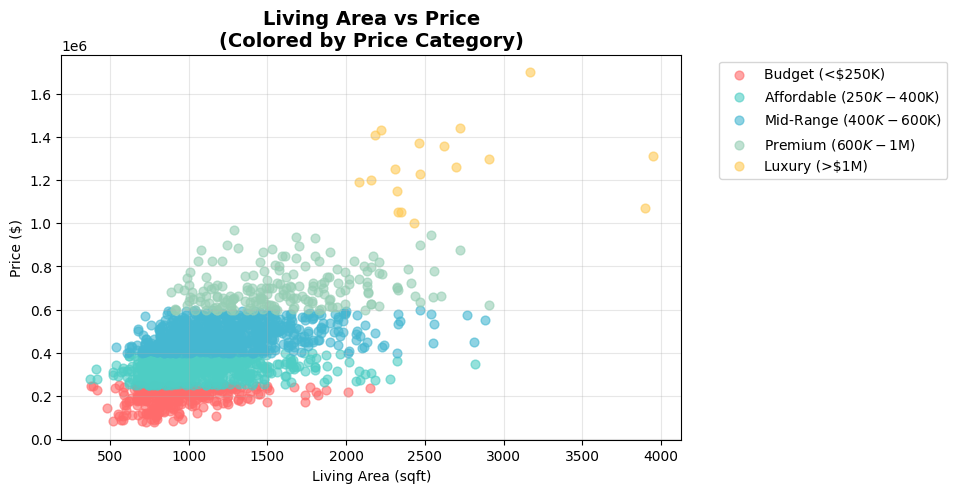

In [243]:
# Chart 3: Price vs Living Area (colored by price category)
#plt.subplot(3, 4, 3)
for category, color in price_colors.items():
    subset = df_cc[df_cc['price_category'] == category]
    plt.scatter(subset['sqft_living'], subset['price'], 
               label=category, alpha=0.6, s=40, color=color)
plt.title('Living Area vs Price\n(Colored by Price Category)', fontsize=14, fontweight='bold')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

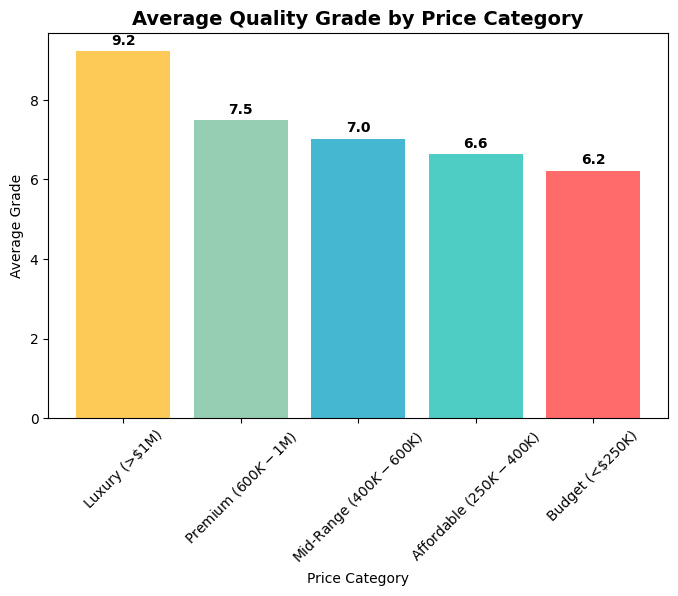

In [244]:
# Chart 6: Average grade by price category
#plt.subplot(3, 4, 6)
avg_grade_by_price = df_cc.groupby('price_category')['grade'].mean().sort_values(ascending=False)
colors = [price_colors[cat] for cat in avg_grade_by_price.index]
plt.bar(avg_grade_by_price.index, avg_grade_by_price.values, color=colors)
plt.title('Average Quality Grade by Price Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Average Grade')
plt.xticks(rotation=45)
# Add values on bars
for i, grade in enumerate(avg_grade_by_price.values):
    plt.text(i, grade + 0.1, f'{grade:.1f}', ha='center', va='bottom', fontweight='bold')

<module 'matplotlib.pyplot' from '/Users/subhadrachakrabarty/Desktop/neuefrische/ds_ai_bootcamp/project_subhadra/week_03_EDA/ds-EDA-project-sc/.venv/lib/python3.11/site-packages/matplotlib/pyplot.py'>

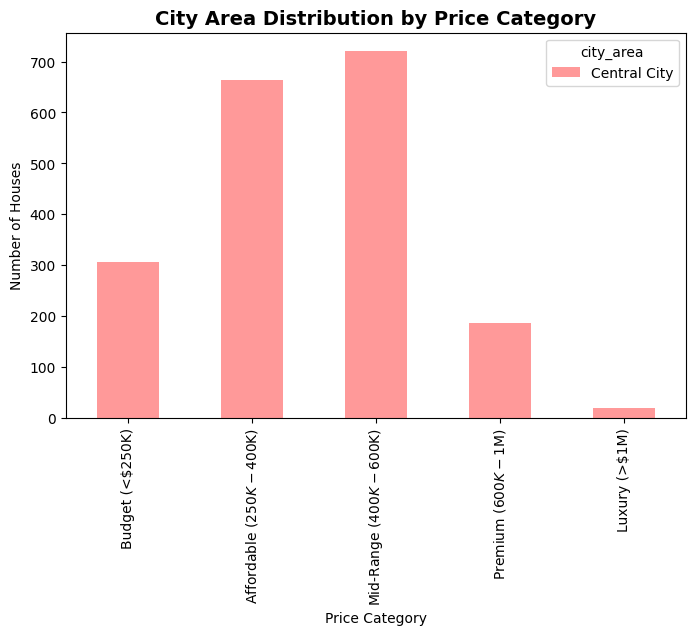

In [245]:
# Chart 9: City area distribution by price category
#plt.subplot(3, 4, 9)
cross_tab_city = pd.crosstab(df_cc['price_category'], df_cc['city_area'])
cross_tab_city.plot(kind='bar', stacked=True, ax=plt.gca(), 
                   color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#C9C9FF'])
plt.title('City Area Distribution by Price Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Number of Houses')
plt

In [249]:
# filter for Budget and Affordable houses
#df_cc_price = df_cc[df_cc['price_category'].isin(['Budget (<$250K)', 'Affordable ($250K-$400K)'])]
df_cc_price = df_cc[df_cc['price_category'].isin(['Budget (<$250K)'])]

print(f"Found {len(df_cc_price)} houses matching your criteria!")

Found 306 houses matching your criteria!


In [250]:
# Check grade categories
print("Available grade categories in your data:")
print(df_cc_price['grade_category'].unique())

Available grade categories in your data:
['Good' 'Below Average' 'Average']


In [266]:
# filter for houses in grade: good, bedrooms 2 and bathroom >1.5
df_cc_grade = df_cc_price[
    (df_cc_price['grade_category'] == 'Good') & 
    (df_cc_price['bedrooms'] == 2)& 
    (df_cc_price['bathrooms'] > 1.5)
]
                          
print(f"Found {len(df_cc_grade)} houses matching your criteria!")

print(df_cc_grade.head(2))

Found 9 houses matching your criteria!
          date      price          id  bedrooms  bathrooms  sqft_living  \
107 2014-07-23 188500.000  3530510041     2.000      1.750     1240.000   
726 2014-06-13 210000.000  3530490070     2.000      1.750     1440.000   

     sqft_lot  floors  waterfront  view  ...  sqft_lot15         location  \
107  2493.000   1.000       0.000 0.000  ...    4966.000  In Seattle City   
726  5680.000   1.000       0.000 0.000  ...    3547.000  In Seattle City   

      price_category  grade_category  bedroom_category  month  month_name  \
107  Budget (<$250K)            Good        Medium (3)      7        July   
726  Budget (<$250K)            Good        Medium (3)      6        June   

     year     city_area  price_per_sqft  
107  2014  Central City         152.016  
726  2014  Central City         145.833  

[2 rows x 30 columns]


In [267]:
# Sort list by sqft_living (descending) then price (ascending)
sorted_cc = df_cc_grade.sort_values(['sqft_living', 'bathrooms', 'price'], ascending=[False, False, True])

# Display the sorted table
display_columns = ['sqft_living', 'price', 'bedrooms', 'bathrooms', 'grade']
sorted_display = sorted_cc[display_columns].copy()

print(f"\n📋 SORTED TABLE:")
print("=" * 100)
print(sorted_display.to_string(index=False))


📋 SORTED TABLE:
 sqft_living      price  bedrooms  bathrooms  grade
    1440.000 210000.000     2.000      1.750      8
    1390.000 216500.000     2.000      1.750      8
    1330.000 202200.000     2.000      1.750      8
    1240.000 188500.000     2.000      1.750      8
    1110.000 229800.000     2.000      1.750      8
    1090.000 149900.000     2.000      1.750      8
    1050.000 187000.000     2.000      1.750      8
    1000.000 210000.000     2.000      1.750      8
     850.000 233000.000     2.000      2.250      8


In [270]:
# Selecting top 5 recommendations based on living space

top_city_houses = sorted_cc.head(5)

In [272]:
## Mapping recommended city houses
# Map center
middle_lat = top_city_houses['lat'].mean()
middle_long = top_city_houses['long'].mean()

map_houses = folium.Map(location=[middle_lat, middle_long], zoom_start=10, tiles='cartodb positron')

# Set bounds
bounds = [
    [top_city_houses['lat'].min(), top_city_houses['long'].min()],
    [top_city_houses['lat'].max(), top_city_houses['long'].max()]
]
map_houses.fit_bounds(bounds)

# Marker cluster for better visualization
marker_cluster = MarkerCluster().add_to(map_houses)

def get_marker_color(price_category):
    color_map = {
        'Budget (<$250K)': 'green',
        'Affordable ($250K-$400K)': 'blue', 
        'Mid-Range ($400K-$600K)': 'orange',
        'Premium ($600K-$1M)': 'purple',
        'Luxury (>$1M)': 'red'
    }
    return color_map.get(price_category, 'gray')

# Add markers
for _, row in top_city_houses.iterrows():
    popup_content = f"""
    <div style="width: 250px;">
        <h4>🏠 House Details</h4>
        <hr>
        <b>Price:</b> ${row['price']:,.0f}<br>
        <b>Bedrooms:</b> {row['bedrooms']}<br>
        <b>Bathrooms:</b> {row['bathrooms']}<br>
        <b>Living Area:</b> {row['sqft_living']} sqft<br>
        <b>Grade:</b> {row.get('grade_category', row.get('grade', 'N/A'))}<br>
        <b>Price Category:</b> {row.get('price_category', 'N/A')}<br>
        <b>Year Built:</b> {row['yr_built']}<br>
        <b>Renovated:</b> {'No' if pd.isna(row['yr_renovated']) or row['yr_renovated']==0 else 'Yes'}
    </div>
    """
    price_cat = row.get('price_category', 'Unknown')
    marker_color = get_marker_color(price_cat)

    folium.Marker(
        location=[row['lat'], row['long']],
        tooltip=f"${row['price']:,.0f} | {row['bedrooms']} bed | Grade: {row.get('grade_category', row.get('grade', 'N/A'))}",
        popup=folium.Popup(popup_content, max_width=300),
        icon=folium.Icon(color=marker_color, icon='home')
    ).add_to(marker_cluster)

print(f"✅ Added {len(top_city_houses)} house markers")

# Add legend
"""legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 180px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px">
     <p><strong>🏠 Price Legend</strong></p>
     <p><span style="color: green;">●</span> Budget (<$250K)</p>
     <p><span style="color: blue;">●</span> Affordable ($250K-$400K)</p>
     <p><span style="color: orange;">●</span> Mid-Range ($400K-$600K)</p>
     <p><span style="color: purple;">●</span> Premium ($600K-$1M)</p>
     <p><span style="color: red;">●</span> Luxury (>$1M)</p>
</div>
'''
"""
#map_houses.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_houses.save("city_house_locations.html")
print("✅ Map saved as 'city_house_locations.html'")


✅ Added 5 house markers
✅ Map saved as 'city_house_locations.html'
